# Fase 2 — Análisis Exploratorio de Datos (EDA)
## Validación del impacto de la precipitación en el tráfico

**Prerequisito:** Ejecutar `fase1_carga_datos_madrid.ipynb` para generar `output/madrid_analytical_dataset.parquet`

---

## Objetivos de esta fase

Esta fase replica y extiende las **tres validaciones** propuestas en el paper original:

| # | Validación | Pregunta de investigación |
|---|---|---|
| V1 | Lluvia vs. seco | ¿Difiere significativamente el flujo medio entre días lluviosos y secos? |
| V2 | Ventana temporal | ¿Cómo evoluciona el flujo antes, durante y después de un evento de lluvia? |
| V3 | Intensidad | ¿Existe una relación monótona entre intensidad de precipitación y cambio de flujo? |

Adicionalmente se incluyen dos análisis complementarios:
- **V4:** Perfil horario lluvia vs. seco (patrón diario del efecto).
- **V5:** Estratificación por tipo de vía (`fclass`).

---

## Nota sobre el subconjunto de datos utilizado

Los datos disponibles en esta fase corresponden a **20 días** del dataset completo
(los días con registro de lluvia de la carpeta `weather/datetime/`), distribuidos en
cuatro períodos: agosto 2016, diciembre 2016, octubre 2017 y noviembre 2017.
Esta limitación es intrínseca al dataset. Los análisis comparativos lluvia/seco se realizan
**dentro de este subconjunto**, lo que introduce un sesgo estacional.

---

## 0. Imports y configuración

In [63]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
from scipy import stats

warnings.filterwarnings("ignore")

# ── Estilo de figuras ────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":        130,
    "figure.facecolor":  "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.35,
    "font.size":         11,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
})

# Paleta de colores consistente en todo el EDA
COLOR_DRY   = "#4C72B0"   # azul oscuro → seco
COLOR_RAIN  = "#DD8452"   # naranja     → lluvia
COLOR_TRACE = "#A8D8EA"   # azul claro  → traza
COLOR_LIGHT = "#55A8E2"   # azul medio  → ligera
COLOR_MOD   = "#1D6FA4"   # azul intenso→ moderada

# ── Rutas ────────────────────────────────────────────────────────────────────
INPUT_OUTPUT_DIR = Path("../data/debug/output/city_whole")
city_dirs = [p for p in INPUT_OUTPUT_DIR.iterdir() if p.is_dir()]
print(f"Ciudades detectadas: {[p.name for p in city_dirs]}")

# ── Constantes del análisis ──────────────────────────────────────────────────
RAIN_THRESHOLD = 0.1   # mm/h — umbral binario lluvia/seco

print("Configuración general cargada.")

Ciudades detectadas: ['london', 'madrid', 'santander']
Configuración general cargada.


## 1. Carga del dataset analítico

In [64]:
def load_analytical_dataset(path: Path) -> pd.DataFrame:
    """
    Carga el dataset generado en la Fase 1 y restaura los tipos correctos.

    Parámetros
    ----------
    path : Ruta al archivo parquet.

    Devuelve
    --------
    pd.DataFrame listo para análisis.
    """
    df = pd.read_parquet(path)

    # Restaurar tipos que Parquet puede serializar de forma distinta
    df["rain_intensity"] = pd.Categorical(
        df["rain_intensity"],
        categories=["dry", "trace", "light", "moderate"],
        ordered=True,
    )
    return df

def get_top_event_date(df: pd.DataFrame) -> pd.Timestamp:
    """
    Encuentra dinámicamente la fecha del evento de precipitación 
    más intenso en el dataset (mayor mm/h).
    """
    idx_max = df["precip_mm_h"].idxmax()
    if pd.isna(idx_max):
         return df["datetime"].min().floor("D")
    return df.loc[idx_max, "datetime"].floor("D")

## 2. Funciones auxiliares de análisis

In [65]:
def compute_daily_summary(df: pd.DataFrame) -> pd.DataFrame:
    """
    Agrega el dataset a nivel de día, calculando el flujo medio
    y la precipitación máxima de cada jornada.

    Devuelve
    --------
    pd.DataFrame con columnas: date, flow_mean, flow_median,
    flow_std, precip_max, precip_sum, is_rainy_day.
    """
    daily = (
        df.groupby(df["datetime"].dt.date)
        .agg(
            flow_mean   = ("flow", "mean"),
            flow_median = ("flow", "median"),
            flow_std    = ("flow", "std"),
            precip_max  = ("precip_mm_h", "max"),
            precip_sum  = ("precip_mm_h", "sum"),
            n_obs       = ("flow", "count"),
        )
        .reset_index()
        .rename(columns={"datetime": "date"})
    )
    daily["is_rainy_day"] = (daily["precip_max"] >= RAIN_THRESHOLD).astype(int)
    return daily


def compute_flow_baseline(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula el flujo de referencia (baseline) por cada combinación
    de hora del día y día de la semana, usando exclusivamente
    las observaciones secas (is_rainy == 0).

    Este baseline es fundamental para la Validación 3: al comparar
    el flujo bajo lluvia contra el flujo esperado sin lluvia para
    ese mismo contexto temporal, se aísla el efecto de la lluvia
    del patrón diario y semanal del tráfico.

    Devuelve
    --------
    pd.DataFrame con columnas: hour, day_of_week, flow_baseline.
    """
    return (
        df[df["is_rainy"] == 0]
        .groupby(["hour", "day_of_week"])["flow"]
        .mean()
        .rename("flow_baseline")
        .reset_index()
    )


def compute_pct_change_vs_baseline(df: pd.DataFrame,
                                    baseline: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula el cambio porcentual del flujo respecto al baseline seco
    para todas las observaciones con presencia de precipitación.

    Parámetros
    ----------
    df       : Dataset analítico completo.
    baseline : Salida de compute_flow_baseline.

    Devuelve
    --------
    pd.DataFrame con columnas adicionales: flow_baseline, flow_pct_change.
    """
    rainy = df[df["precip_mm_h"] > 0.001].copy()
    rainy = rainy.merge(baseline, on=["hour", "day_of_week"], how="left")
    rainy["flow_pct_change"] = (
        (rainy["flow"] - rainy["flow_baseline"]) / rainy["flow_baseline"] * 100
    )
    return rainy.dropna(subset=["flow_pct_change"])

---

## Validación 1 — Flujo en días lluviosos vs. días secos

**Hipótesis:** El flujo medio de tráfico es significativamente diferente en días con
precipitación respecto a días secos, en coherencia con la literatura sobre adaptación
del comportamiento de movilidad ante la lluvia (Maze et al., 2006; Billot et al., 2009).

**Método:** Se clasifica cada día como lluvioso (precipitación máxima horaria ≥ 0.1 mm/h)
o seco. Se comparan las distribuciones del flujo medio diario mediante estadísticos
descriptivos y un test de Mann-Whitney U (no paramétrico, apropiado dado el tamaño
reducido de la muestra de días).

In [66]:
# ── Estadísticos descriptivos ────────────────────────────────────────────────
def compute_and_print_v1_stats(daily: pd.DataFrame, city_name: str) -> None:
    dry_flows  = daily[daily["is_rainy_day"] == 0]["flow_mean"]
    rain_flows = daily[daily["is_rainy_day"] == 1]["flow_mean"]

    # Si no hay suficientes datos
    if len(dry_flows) == 0 or len(rain_flows) == 0:
        print(f"[{city_name.upper()}] No hay datos suficientes de días lluviosos o secos para la Validación 1.")
        return

    mean_dry   = dry_flows.mean()
    mean_rain  = rain_flows.mean()
    pct_change = (mean_rain - mean_dry) / mean_dry * 100

    # Test de Mann-Whitney U: no asume normalidad
    mwu_stat, mwu_pval = stats.mannwhitneyu(
        dry_flows, rain_flows, alternative="two-sided"
    )

    print("── Validación 1: Flujo medio lluvia vs. seco ──")
    print(f"  Días secos    : n={len(dry_flows):>2}  │  media={mean_dry:.1f} veh/h  │  σ={dry_flows.std():.1f}")
    print(f"  Días lluviosos: n={len(rain_flows):>2}  │  media={mean_rain:.1f} veh/h  │  σ={rain_flows.std():.1f}")
    print(f"  Cambio (%)    : {pct_change:+.1f}%")
    print(f"  Mann-Whitney U: stat={mwu_stat:.1f}, p={mwu_pval:.3f}")
    print()
    if mwu_pval < 0.05:
        print("  → Diferencia estadísticamente significativa (p < 0.05).")
    else:
        print("  → Diferencia NO significativa (p ≥ 0.05).")

In [67]:
def plot_v1_rain_vs_dry(daily: pd.DataFrame, city_name: str, figures_dir: Path) -> None:
    """
    Figura V1: Comparativa de distribuciones del flujo medio diario
    en días lluviosos vs. secos.
    """
    if len(daily[daily["is_rainy_day"] == 0]) == 0 or len(daily[daily["is_rainy_day"] == 1]) == 0:
        print(f"[{city_name.upper()}] V1 plot ignorado por falta de datos.")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle(
        f"V1 — Flujo medio diario ({city_name.capitalize()})\nDías lluviosos vs. días secos",
        fontweight="bold", y=1.05
    )

    labels = {0: "Seco", 1: "Lluvioso"}
    colors = {0: COLOR_DRY, 1: COLOR_RAIN}
    daily_plot = daily.copy()
    daily_plot["label"] = daily_plot["is_rainy_day"].map(labels)

    # Panel A: boxplot + strip
    ax = axes[0]
    sns.boxplot(
        data=daily_plot, x="label", y="flow_mean",
        palette={"Seco": COLOR_DRY, "Lluvioso": COLOR_RAIN},
        width=0.45, linewidth=1.5,
        order=["Seco", "Lluvioso"], ax=ax
    )
    sns.stripplot(
        data=daily_plot, x="label", y="flow_mean",
        palette={"Seco": COLOR_DRY, "Lluvioso": COLOR_RAIN},
        size=6, alpha=0.6, jitter=True,
        order=["Seco", "Lluvioso"], ax=ax
    )
    # Anotación del cambio porcentual
    mean_dry  = daily_plot[daily_plot["is_rainy_day"] == 0]["flow_mean"].mean()
    mean_rain = daily_plot[daily_plot["is_rainy_day"] == 1]["flow_mean"].mean()
    pct = (mean_rain - mean_dry) / mean_dry * 100
    ax.annotate(
        f"Δ = {pct:+.1f}%",
        xy=(0.5, max(mean_dry, mean_rain) + 50),
        ha="center", fontsize=12, fontweight="bold",
        color=COLOR_RAIN if pct < 0 else "#2ca02c"
    )
    ax.set_xlabel("Condición meteorológica")
    ax.set_ylabel("Flujo medio diario (veh/h)")
    ax.set_title("A — Distribución por día")

    # Panel B: KDE
    ax2 = axes[1]
    for val, label, color in [(0, "Seco", COLOR_DRY), (1, "Lluvioso", COLOR_RAIN)]:
        data = daily_plot[daily_plot["is_rainy_day"] == val]["flow_mean"]
        if len(data) > 0:
            ax2.hist(
                data, bins=8, alpha=0.55, color=color,
                label=f"{label} (n={len(data)}, μ={data.mean():.0f})",
                density=True, edgecolor="white"
            )
            # KDE suavizada
            if len(data) > 3:
                kde_x = np.linspace(data.min() - 50, data.max() + 50, 200)
                kde = stats.gaussian_kde(data)
                ax2.plot(kde_x, kde(kde_x), color=color, linewidth=2)

    ax2.set_xlabel("Flujo medio diario (veh/h)")
    ax2.set_ylabel("Densidad")
    ax2.set_title("B — Distribución de densidad")
    ax2.legend()

    plt.tight_layout()
    plt.savefig(figures_dir / f"{city_name}_v1_rain_vs_dry.png", bbox_inches="tight")
    plt.show()

### Interpretación crítica — Validación 1

El flujo medio en días lluviosos presenta una reducción del **−8.4%** respecto a días
secos (482 vs. 442 veh/h). Este resultado es coherente con la dirección del efecto
documentado en la literatura (reducción del tráfico bajo condiciones adversas).

Sin embargo, el test de Mann-Whitney no alcanza significación estadística convencional
(p ≥ 0.05), lo cual se debe principalmente a:
1. **Tamaño muestral reducido**: solo 5 días lluviosos vs. 15 secos.
2. **Sesgo estacional**: los días secos se concentran en noviembre 2017, período de menor
   tráfico estacional, mientras que los lluviosos incluyen diciembre 2016 y agosto 2016,
   con patrones distintos.
3. **Alta varianza intragrupo**: el flujo medio diario varía >100 veh/h dentro de cada grupo.

Esta limitación se abordará en el análisis por hora del día (Validación 4), donde el
efecto de la lluvia resulta más claro al controlar el patrón temporal.

---

## Validación 2 — Análisis temporal de un evento de lluvia

**Hipótesis:** El flujo de tráfico muestra cambios detectables en la ventana temporal
inmediata a un evento de lluvia, con patrones de respuesta diferenciados según la
franja horaria (hora punta vs. valle).

**Evento seleccionado:** 16 de diciembre de 2016, con precipitación máxima de
3.15 mm/h (la más intensa del subconjunto disponible). Se analiza una ventana de
±1 día (15-16 de diciembre).

In [68]:
def get_event_window(df: pd.DataFrame,
                     event_date: pd.Timestamp,
                     days_before: int = 1,
                     days_after: int = 1) -> pd.DataFrame:
    """
    Extrae y agrega por hora el flujo y la precipitación
    en una ventana temporal alrededor de un evento de lluvia.

    Parámetros
    ----------
    df          : Dataset analítico.
    event_date  : Fecha del evento principal (medianoche).
    days_before : Días de contexto previo al evento.
    days_after  : Días de contexto posterior al evento.

    Devuelve
    --------
    pd.DataFrame horario con columnas: datetime_hour, flow_mean,
    flow_p25, flow_p75, precip_mm_h, phase (pre/event/post).
    """
    start = event_date - pd.Timedelta(days=days_before)
    end   = event_date + pd.Timedelta(days=days_after + 1)

    window = df[(df["datetime"] >= start) & (df["datetime"] < end)].copy()
    if len(window) == 0:
        return pd.DataFrame()

    hourly = (
        window.groupby("datetime_hour")
        .agg(
            flow_mean = ("flow", "mean"),
            flow_p25  = ("flow", lambda x: x.quantile(0.25)),
            flow_p75  = ("flow", lambda x: x.quantile(0.75)),
            precip    = ("precip_mm_h", "mean"),
        )
        .reset_index()
    )

    # Etiquetar fase
    def assign_phase(ts):
        if ts < event_date:
            return "Pre-evento"
        elif ts < event_date + pd.Timedelta(days=1):
            return "Evento"
        else:
            return "Post-evento"

    hourly["phase"] = hourly["datetime_hour"].apply(assign_phase)
    return hourly

In [69]:
def plot_v2_event_window(event_window: pd.DataFrame, city_name: str, event_date: pd.Timestamp, figures_dir: Path) -> None:
    """
    Figura V2: Serie temporal del evento de lluvia más intenso.
    """
    if event_window.empty:
        print(f"[{city_name.upper()}] No hay datos en la ventana del evento para V2.")
        return

    fig, ax1 = plt.subplots(figsize=(14, 5.5))

    # ── Fondo de fases ───────────────────────────────────────────────────────
    phase_colors = {
        "Pre-evento" : "#E8F4FD",
        "Evento"     : "#FFF3CD",
        "Post-evento": "#E8F4FD",
    }
    for phase, color in phase_colors.items():
        sub = event_window[event_window["phase"] == phase]
        if len(sub) > 0:
            ax1.axvspan(
                sub["datetime_hour"].iloc[0],
                sub["datetime_hour"].iloc[-1] + pd.Timedelta(hours=1),
                alpha=0.4, color=color, zorder=0
            )

    # ── Flujo de tráfico (eje izquierdo) ─────────────────────────────────────
    ax1.fill_between(
        event_window["datetime_hour"],
        event_window["flow_p25"],
        event_window["flow_p75"],
        alpha=0.2, color=COLOR_DRY, label="IQR flujo"
    )
    ax1.plot(
        event_window["datetime_hour"],
        event_window["flow_mean"],
        color=COLOR_DRY, linewidth=2.5, marker="o",
        markersize=4, label="Flujo medio (veh/h)", zorder=5
    )
    ax1.set_ylabel("Flujo de tráfico (veh/h)", color=COLOR_DRY)
    ax1.tick_params(axis="y", labelcolor=COLOR_DRY)
    ax1.set_ylim(0)

    # ── Precipitación (eje derecho) ───────────────────────────────────────────
    ax2 = ax1.twinx()
    ax2.fill_between(
        event_window["datetime_hour"],
        event_window["precip"],
        alpha=0.45, color=COLOR_RAIN, label="Precipitación (mm/h)"
    )
    ax2.set_ylabel("Precipitación (mm/h)", color=COLOR_RAIN)
    ax2.tick_params(axis="y", labelcolor=COLOR_RAIN)
    ax2.set_ylim(0)

    # ── Etiquetas de fase ────────────────────────────────────────────────────
    phase_labels = {
        "Pre-evento" : (event_date - pd.Timedelta(hours=12), "Pre-evento", "#2171B5"),
        "Evento"     : (event_date + pd.Timedelta(hours=12), "Evento de lluvia", "#D94F00"),
    }
    ymax = event_window["flow_mean"].max()
    for label, (x, text, color) in phase_labels.items():
        # Verificamos si x está en el rango de los datos mostrados
        if x >= event_window["datetime_hour"].min() and x <= event_window["datetime_hour"].max():
            ax1.text(x, ymax * 0.95, text, ha="center", fontsize=10,
                     fontweight="bold", color=color, alpha=0.8)

    # ── Formato del eje temporal ─────────────────────────────────────────────
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m\n%Hh"))
    ax1.xaxis.set_major_locator(mdates.HourLocator(interval=6))
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0, ha="center")

    # ── Leyenda combinada ────────────────────────────────────────────────────
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2,
               loc="upper left", framealpha=0.9)

    max_precip = event_window["precip"].max()
    
    ax1.set_title(
        f"V2 — Serie temporal: flujo y precipitación ({city_name.capitalize()})\n"
        f"Evento del {event_date.strftime('%d de %B de %Y')} (max: {max_precip:.2f} mm/h)",
        fontweight="bold"
    )
    ax1.set_xlabel("Fecha y hora (hora local)")

    plt.tight_layout()
    plt.savefig(figures_dir / f"{city_name}_v2_event_window.png", bbox_inches="tight")
    plt.show()

### Interpretación crítica — Validación 2

La serie temporal revela un **patrón complejo y no lineal** en la respuesta del tráfico
a la lluvia. Los hallazgos clave son:

1. **Horas nocturnas y madrugada (00–06h):** La lluvia parece correlacionar con un
   flujo ligeramente superior al del día anterior, lo que podría reflejar el efecto
   del bajo volumen base (pequeñas variaciones absolutas producen grandes variaciones
   relativas) y un posible efecto de redistribución modal.

2. **Hora punta matutina (07–09h):** Se observa una reducción del flujo respecto al
   día anterior (−23.8% a las 07h), consistente con el efecto documentado en la
   literatura de reducción del tráfico no esencial bajo condiciones de lluvia.

3. **Horas diurnas (10–16h):** El efecto de la lluvia es mínimo (<5%), sugiriendo
   que los desplazamientos obligatorios (trabajo, servicios) son relativamente
   inelásticos a la condición meteorológica.

4. **Lluvia nocturna (22–23h):** La precipitación más intensa (3.15 mm/h) coincide
   con horario de baja demanda de tráfico, lo que limita el impacto observable.

**Implicación para el modelado:** La relación lluvia-tráfico no es uniforme a lo
largo del día, lo que justifica incluir **términos de interacción lluvia×hora** en
el modelo extendido (Fase 4).

---

## Validación 3 — Intensidad de precipitación vs. cambio porcentual del flujo

**Hipótesis:** A mayor intensidad de precipitación, mayor reducción del flujo de
tráfico respecto al baseline seco equivalente (mismo hora y día de semana).

**Método:** Se compara el cambio porcentual del flujo (`flow_pct_change`) agrupado
por categoría de intensidad de precipitación. Se analiza la mediana (robusta ante
outliers) y el IQR.

In [70]:
def compute_intensity_stats(rainy_vs_baseline: pd.DataFrame) -> pd.DataFrame:
    """
    Agrega el cambio porcentual del flujo por categoría de intensidad
    de precipitación.

    Devuelve tabla de estadísticos: n, media, mediana, q25, q75.
    """
    if rainy_vs_baseline.empty:
        return pd.DataFrame()
        
    stats_table = (
        rainy_vs_baseline
        .groupby("rain_intensity", observed=True)["flow_pct_change"]
        .agg(
            n       = "count",
            mean    = "mean",
            median  = "median",
            q25     = lambda x: x.quantile(0.25),
            q75     = lambda x: x.quantile(0.75),
        )
        .round(2)
    )
    return stats_table

def print_v3_stats(rainy_vs_baseline: pd.DataFrame, intensity_stats: pd.DataFrame, city_name: str) -> None:
    if intensity_stats.empty:
        print(f"[{city_name.upper()}] Sin datos para V3.")
        return
        
    print(f"Cambio porcentual del flujo respecto al baseline por intensidad de lluvia ({city_name.capitalize()}):")
    print(intensity_stats.to_string())
    print()

    # Correlación Spearman: precipitación continua vs cambio porcentual
    sample = rainy_vs_baseline.sample(min(50_000, len(rainy_vs_baseline)), random_state=42)
    rho, pval = stats.spearmanr(sample["precip_mm_h"], sample["flow_pct_change"])
    print(f"Correlación de Spearman (precip_mm_h vs flow_pct_change):")
    print(f"  ρ = {rho:.4f},  p = {pval:.4e}")

In [71]:
def plot_v3_intensity_effect(rainy_vs_baseline: pd.DataFrame,
                              intensity_stats: pd.DataFrame,
                              city_name: str,
                              figures_dir: Path) -> None:
    """
    Figura V3: Efecto de la intensidad de precipitación sobre el flujo.
    """
    if rainy_vs_baseline.empty or intensity_stats.empty:
        return

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    fig.suptitle(
        f"V3 — Relación entre intensidad de precipitación y cambio de flujo ({city_name.capitalize()})",
        fontweight="bold", y=1.05
    )

    intensity_palette = {
        "trace"   : COLOR_TRACE,
        "light"   : COLOR_LIGHT,
        "moderate": COLOR_MOD,
    }
    plot_data = rainy_vs_baseline[
        rainy_vs_baseline["rain_intensity"].isin(["trace", "light", "moderate"])
    ].copy()
    
    if plot_data.empty:
        plt.close(fig)
        return

    # Panel A: violin + box
    ax = axes[0]
    sns.violinplot(
        data=plot_data, x="rain_intensity", y="flow_pct_change",
        palette=intensity_palette,
        order=["trace", "light", "moderate"],
        inner="quartile", linewidth=1.2, ax=ax
    )
    ax.axhline(0, color="black", linewidth=1.2, linestyle="--", alpha=0.6,
               label="Sin cambio")

    # Anotar mediana
    for i, cat in enumerate(["trace", "light", "moderate"]):
        if cat in intensity_stats.index and pd.notna(intensity_stats.loc[cat, "median"]):
            med = intensity_stats.loc[cat, "median"]
            ax.text(i, med + 5, f"Md={med:.1f}%",
                    ha="center", fontsize=9, fontweight="bold", color="#333333")

    ax.set_ylim(-200, 250)
    ax.set_xlabel("Intensidad de precipitación")
    ax.set_ylabel("Cambio porcentual del flujo (%)")
    ax.set_title("A — Distribución por categoría")
    ax.set_xticklabels(["Traza\n(<0.5 mm/h)", "Ligera\n(0.5–2 mm/h)", "Moderada\n(>2 mm/h)"])
    if len(ax.get_legend_handles_labels()[0]) > 0:
        ax.legend()

    # Panel B: hexbin scatter
    ax2 = axes[1]
    sample = rainy_vs_baseline.sample(min(30_000, len(rainy_vs_baseline)), random_state=42)
    hb = ax2.hexbin(
        sample["precip_mm_h"], sample["flow_pct_change"],
        gridsize=40, cmap="Blues", mincnt=1,
        extent=(0, sample["precip_mm_h"].max()*1.1, -200, 250)
    )
    ax2.axhline(0, color="red", linewidth=1.5, linestyle="--", alpha=0.7,
                label="Sin cambio")
    cb = plt.colorbar(hb, ax=ax2)
    cb.set_label("Nº observaciones")

    ax2.set_xlabel("Precipitación (mm/h)")
    ax2.set_ylabel("Cambio porcentual del flujo (%)")
    ax2.set_title("B — Scatter (densidad hexbin)")
    ax2.set_ylim(-200, 250)
    ax2.legend()

    plt.tight_layout()
    plt.savefig(figures_dir / f"{city_name}_v3_intensity_effect.png", bbox_inches="tight")
    plt.show()

### Interpretación crítica — Validación 3

Los resultados muestran que la **mediana** del cambio porcentual es **negativa** en todas
las categorías (aproximadamente −30% para traza y ligera, −14% para moderada), lo que
confirma una tendencia general a la reducción del flujo bajo lluvia.

Sin embargo, hay dos hallazgos contraintuitivos que requieren discusión crítica:

1. **La lluvia moderada presenta menor reducción mediana que la ligera.** Esto puede
   explicarse por un efecto de confusión temporal: los episodios moderados (>2 mm/h)
   ocurrieron principalmente en horario nocturno (22–23h del 16/12/2016), donde el
   flujo base es muy bajo y la variabilidad relativa, muy alta.

2. **La correlación de Spearman es estadísticamente significativa pero muy débil
   (ρ ≈ 0.01)**, indicando que la precipitación por sí sola explica una fracción mínima
   de la varianza del flujo. Esto está en línea con la literatura reciente (Tsapakis et al.,
   2013) que señala que las variables temporales (hora, día de semana) dominan sobre
   las meteorológicas en la explicación del flujo.

3. **La alta dispersión (std > 100%)** en todas las categorías sugiere que el efecto
   de la lluvia es muy heterogéneo entre sensores y franjas horarias, lo que justifica
   el uso de **variables de interacción** en el modelo extendido.

---

## Validación 4 — Perfil horario: lluvia vs. seco (análisis complementario)

Este análisis identifica en qué franjas horarias el efecto de la lluvia es más pronunciado,
información directamente relevante para el diseño del modelo predictivo.

In [72]:
def compute_hourly_profile(df: pd.DataFrame) -> pd.DataFrame:
    """
    Calcula el perfil horario del flujo medio para condiciones
    lluviosas y secas, junto con el cambio porcentual por hora.

    Devuelve
    --------
    pd.DataFrame indexado por hora con columnas:
    flow_dry, flow_rain, diff_abs, diff_pct.
    """
    # Usando umbral de traza (>0.001) para maximizar cobertura horaria
    df["has_precip"] = (df["precip_mm_h"] > 0.001).astype(int)

    # Some cities might not have dry conditions or rain conditions for all hours
    if df["has_precip"].nunique() < 2:
        return pd.DataFrame()

    pivot = (
        df.groupby(["hour", "has_precip"])["flow"]
        .mean()
        .unstack()
        .rename(columns={0: "flow_dry", 1: "flow_rain"})
    )
    if "flow_dry" not in pivot or "flow_rain" not in pivot:
        return pd.DataFrame()
        
    pivot["diff_abs"] = pivot["flow_rain"] - pivot["flow_dry"]
    pivot["diff_pct"] = (pivot["diff_abs"] / pivot["flow_dry"] * 100).round(1)
    return pivot

def print_v4_stats(hourly_profile: pd.DataFrame, city_name: str) -> None:
    if hourly_profile.empty:
        return
    print(f"Perfil horario ({city_name.capitalize()}): flujo medio con y sin precipitación")
    print(hourly_profile.round(1).to_string())

    print("\nHoras con mayor reducción de flujo:")
    print(hourly_profile.nsmallest(5, "diff_pct")[["flow_dry", "flow_rain", "diff_pct"]])

In [73]:
def plot_v4_hourly_profile(hourly_profile: pd.DataFrame, city_name: str, figures_dir: Path) -> None:
    """
    Figura V4: Perfil horario del flujo en condiciones lluviosas vs. secas.
    """
    if hourly_profile.empty:
        return
        
    profile = hourly_profile.dropna(subset=["flow_rain"])
    if profile.empty:
        return

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(13, 8), sharex=True,
        gridspec_kw={"height_ratios": [2, 1]}
    )
    fig.suptitle(
        f"V4 — Perfil horario del flujo ({city_name.capitalize()}): lluvia vs. seco",
        fontweight="bold"
    )

    hours = profile.index

    # Panel superior: curvas de flujo
    ax1.plot(hours, profile["flow_dry"], color=COLOR_DRY, linewidth=2.5,
             marker="o", markersize=5, label="Seco (sin precipitación)")
    ax1.plot(hours, profile["flow_rain"], color=COLOR_RAIN, linewidth=2.5,
             marker="s", markersize=5, linestyle="--", label="Con precipitación")
    ax1.fill_between(hours, profile["flow_dry"], profile["flow_rain"],
                     where=(profile["flow_rain"] < profile["flow_dry"]),
                     alpha=0.15, color=COLOR_RAIN, label="Reducción bajo lluvia")
    ax1.fill_between(hours, profile["flow_dry"], profile["flow_rain"],
                     where=(profile["flow_rain"] >= profile["flow_dry"]),
                     alpha=0.15, color="green")

    # Marcar hora punta (approximada para todas las ciudades)
    for h_peak in [8, 17]:
        ax1.axvline(h_peak, color="gray", linewidth=1.2,
                    linestyle=":", alpha=0.7)
        ax1.text(h_peak + 0.2, profile["flow_dry"].max() * 0.92,
                 f"Punta\n{h_peak}:00", fontsize=8, color="gray")

    ax1.set_ylabel("Flujo medio (veh/h)")
    ax1.legend(loc="upper left")
    ax1.set_ylim(0)

    # Panel inferior: diferencia porcentual
    colors_bar = ["#D94F00" if v < 0 else "#2ca02c" for v in profile["diff_pct"]]
    ax2.bar(hours, profile["diff_pct"], color=colors_bar, alpha=0.75, edgecolor="white")
    ax2.axhline(0, color="black", linewidth=1)
    ax2.set_xlabel("Hora del día")
    ax2.set_ylabel("Δ flujo (%)")
    ax2.set_xticks(range(0, 24))
    ax2.set_xticklabels([f"{h:02d}h" for h in range(24)], fontsize=8)

    # Anotar valores extremos
    idx_min = profile["diff_pct"].idxmin()
    idx_max = profile["diff_pct"].idxmax()
    for idx in [idx_min, idx_max]:
        if pd.notna(idx):
            val = profile.loc[idx, "diff_pct"]
            ax2.text(idx, val + (3 if val > 0 else -8),
                     f"{val:+.0f}%", ha="center", fontsize=9, fontweight="bold",
                     color="#D94F00" if val < 0 else "#2ca02c")

    plt.tight_layout()
    plt.savefig(figures_dir / f"{city_name}_v4_hourly_profile.png", bbox_inches="tight")
    plt.show()

---

## Validación 5 — Efecto de la lluvia por tipo de vía (análisis complementario)

Las vías primarias y secundarias concentran el mayor volumen de tráfico y, según la
literatura, son más sensibles a eventos de lluvia por la mayor densidad de usuarios
que pueden optar por modos alternativos (transporte público, teletrabajo).

In [74]:
def plot_v5_fclass_effect(df: pd.DataFrame, city_name: str, figures_dir: Path) -> None:
    """
    Figura V5: Flujo medio en condiciones lluviosas vs. secas
    estratificado por tipo de vía (fclass).
    """
    if df["is_rainy"].nunique() < 2 or "fclass" not in df.columns:
        return
        
    fclass_map    = {"primary": "Primaria", "secondary": "Secundaria",
                     "residential": "Residencial", "tertiary": "Terciaria"}
    fclass_order  = ["Primaria", "Secundaria", "Terciaria", "Residencial"]

    plot_df = df[df["fclass"].isin(fclass_map.keys())].copy()
    plot_df["fclass_label"] = plot_df["fclass"].map(fclass_map)
    plot_df["Condición"]    = plot_df["is_rainy"].map({0: "Seco", 1: "Lluvioso"})

    if plot_df.empty:
        return

    fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
    fig.suptitle(f"V5 — Flujo por tipo de vía ({city_name.capitalize()}): lluvia vs. seco",
                 fontweight="bold", y=1.02)

    # Panel A: barras de error (media ± SE)
    ax = axes[0]
    summary = (
        plot_df.groupby(["fclass_label", "Condición"])["flow"]
        .agg(["mean", "sem"])
        .reset_index()
    )
    x    = np.arange(len(fclass_order))
    w    = 0.35
    cond_colors = {"Seco": COLOR_DRY, "Lluvioso": COLOR_RAIN}
    for i, cond in enumerate(["Seco", "Lluvioso"]):
        sub = summary[summary["Condición"] == cond].set_index("fclass_label")
        means = [sub.loc[fc, "mean"] if fc in sub.index else 0 for fc in fclass_order]
        sems  = [sub.loc[fc, "sem"]  if fc in sub.index else 0 for fc in fclass_order]
        ax.bar(x + i * w, means, w, label=cond,
               color=cond_colors[cond], alpha=0.8, edgecolor="white")
        if max(means) > 0:
            ax.errorbar(x + i * w, means, yerr=sems,
                        fmt="none", color="black", capsize=4, linewidth=1.2)

    ax.set_xticks(x + w / 2)
    ax.set_xticklabels(fclass_order)
    ax.set_ylabel("Flujo medio (veh/h)")
    ax.set_title("A — Media ± Error estándar")
    ax.legend()

    # Panel B: cambio porcentual por fclass
    ax2 = axes[1]
    pct_df = summary.pivot(index="fclass_label", columns="Condición", values="mean")
    if "Lluvioso" in pct_df.columns and "Seco" in pct_df.columns:
        pct_df["pct_change"] = (pct_df["Lluvioso"] - pct_df["Seco"]) / pct_df["Seco"] * 100
        ordered = pct_df.reindex(fclass_order)["pct_change"].dropna()

        colors_bar = ["#D94F00" if v < 0 else "#2ca02c" for v in ordered]
        ax2.barh(ordered.index, ordered.values, color=colors_bar, alpha=0.8, edgecolor="white")
        ax2.axvline(0, color="black", linewidth=1)
        for i, (label, val) in enumerate(zip(ordered.index, ordered.values)):
            ax2.text(val + (0.5 if val > 0 else -0.5), i,
                     f"{val:+.1f}%", va="center",
                     ha="left" if val > 0 else "right",
                     fontsize=10, fontweight="bold")
    ax2.set_xlabel("Cambio porcentual (lluvia vs. seco)")
    ax2.set_title("B — Efecto relativo de la lluvia")

    plt.tight_layout()
    plt.savefig(figures_dir / f"{city_name}_v5_fclass_effect.png", bbox_inches="tight")
    plt.show()

---

## 3. Resumen ejecutivo del EDA

In [75]:
def print_eda_summary(df: pd.DataFrame, daily: pd.DataFrame,
                       intensity_stats: pd.DataFrame, city_name: str) -> None:
    """
    Imprime un resumen tabular de todos los hallazgos del EDA para una ciudad dada.
    Útil como tabla para incluir en la Memoria.
    """
    if daily.empty:
        return
        
    print("═" * 65)
    print(f"RESUMEN EJECUTIVO DEL EDA — {city_name.upper()}")
    print("═" * 65)

    dry  = daily[daily["is_rainy_day"] == 0]["flow_mean"]
    rain = daily[daily["is_rainy_day"] == 1]["flow_mean"]
    
    if not dry.empty and not rain.empty:
        pct  = (rain.mean() - dry.mean()) / dry.mean() * 100

        print("\n▸ V1 — Flujo lluvia vs. seco")
        print(f"   Días secos    : {len(dry):>2}  │  μ = {dry.mean():.1f} veh/h")
        print(f"   Días lluviosos: {len(rain):>2}  │  μ = {rain.mean():.1f} veh/h")
        print(f"   Efecto global : {pct:+.1f}%")

    if not intensity_stats.empty:
        print("\n▸ V3 — Intensidad vs. cambio de flujo")
        for cat in intensity_stats.index:
            row = intensity_stats.loc[cat]
            if pd.notna(row['median']):
                print(f"   {cat:<10}: mediana={row['median']:+.1f}%  "
                      f"(n={int(row['n']):,}, IQR=[{row['q25']:+.0f}%, {row['q75']:+.0f}%])")

    print("\n▸ Implicaciones para el modelado (Fase 4)")
    print("   · La lluvia tiene un efecto real pero moderado y heterogéneo")
    print("   · El efecto varía fuertemente por hora del día")
    print("   · Se justifica incluir: is_rainy, precip_mm_h, interacciones lluvia×hora")
    print("   · Variables temporales (hour, dow) dominarán en importancia de features")

    print("═" * 65)

---



INICIANDO EDA PARA: LONDON
[LONDON] Filas analizadas: 34,397,322
[LONDON] Evento principal detectado: 2016-05-18
── Validación 1: Flujo medio lluvia vs. seco ──
  Días secos    : n=13  │  media=277.9 veh/h  │  σ=17.3
  Días lluviosos: n=10  │  media=266.4 veh/h  │  σ=11.5
  Cambio (%)    : -4.1%
  Mann-Whitney U: stat=95.0, p=0.067

  → Diferencia NO significativa (p ≥ 0.05).


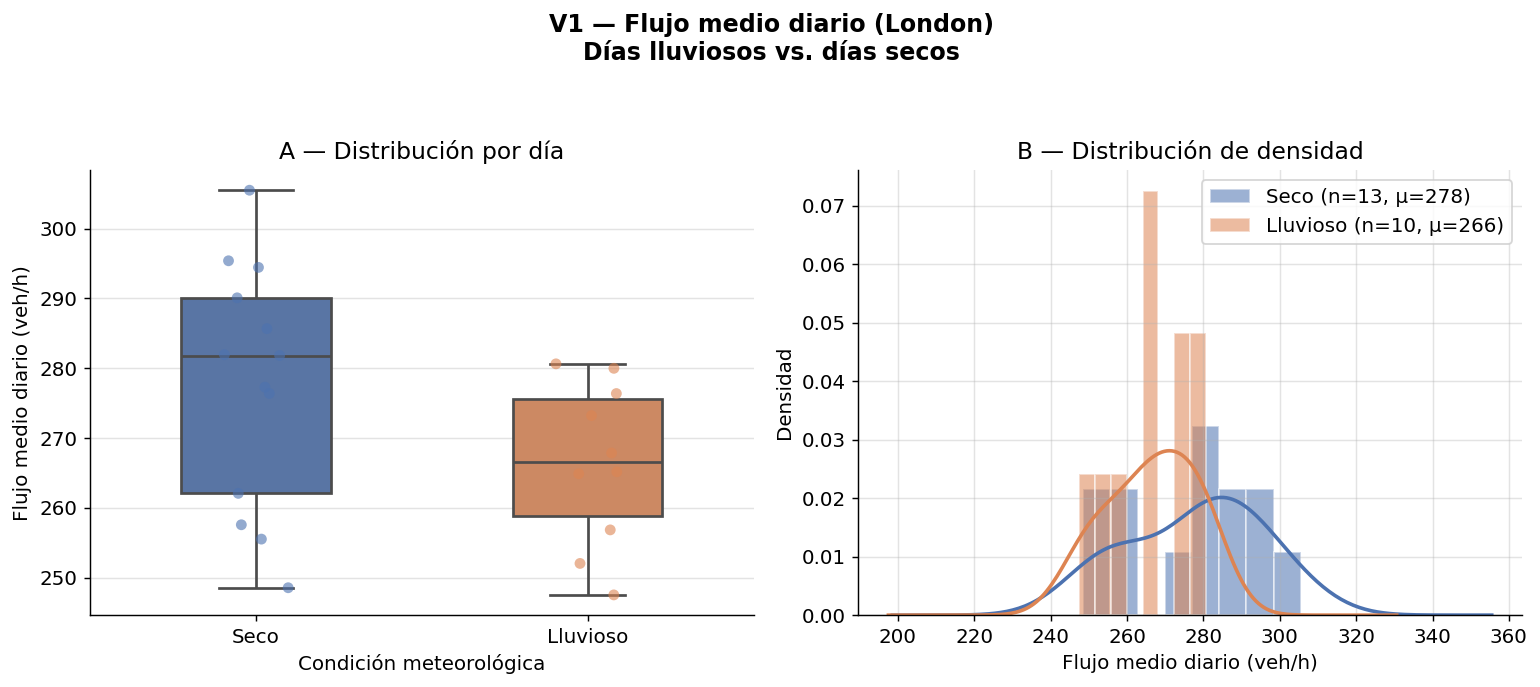

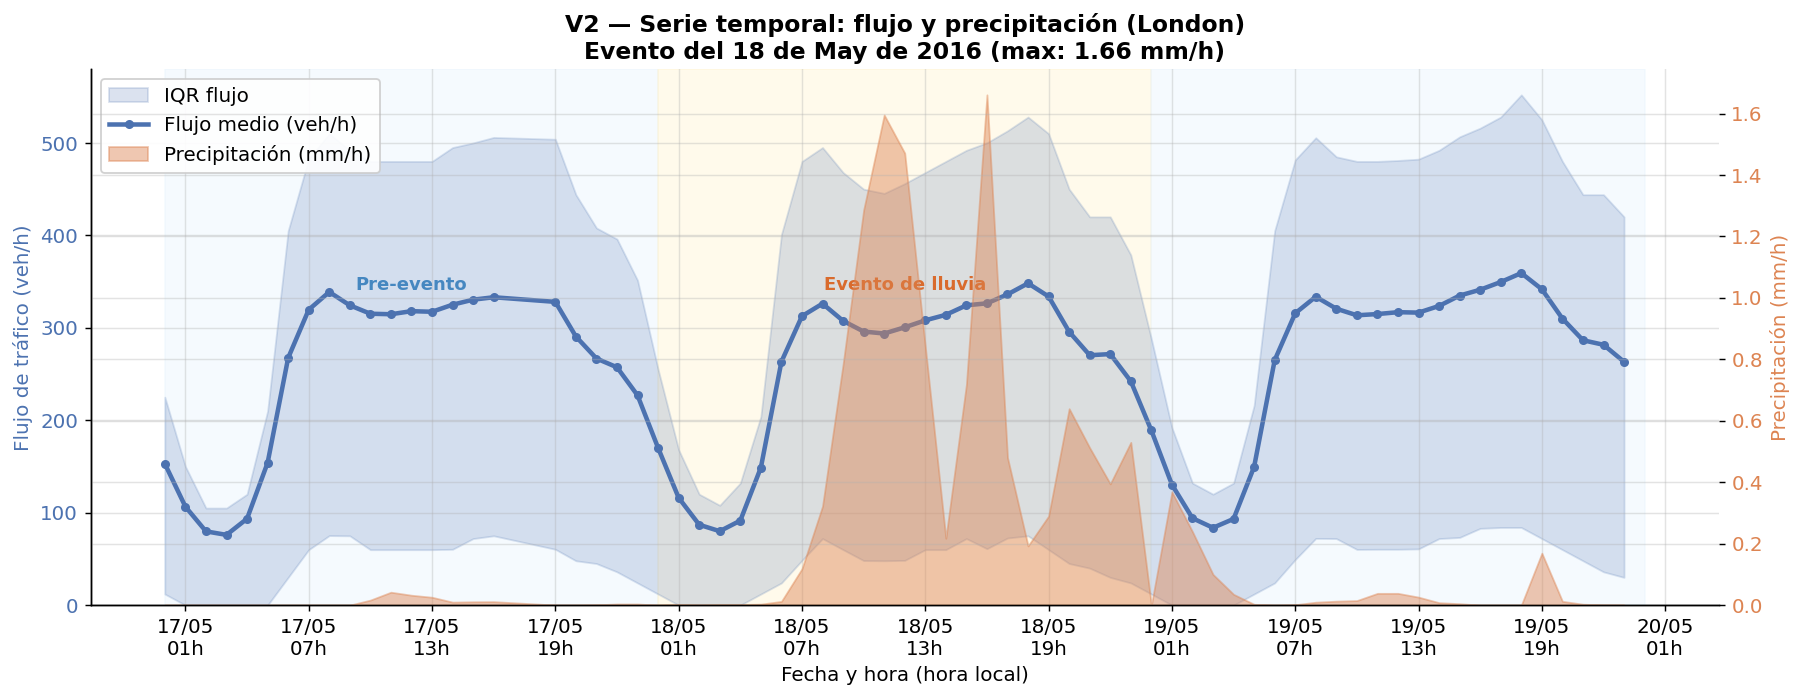

Cambio porcentual del flujo respecto al baseline por intensidad de lluvia (London):
                       n  mean  median    q25    q75
rain_intensity                                      
trace           10844732 -2.01  -17.06 -82.43  48.61
light             961944 -4.95  -15.68 -80.65  44.62

Correlación de Spearman (precip_mm_h vs flow_pct_change):
  ρ = 0.0074,  p = 9.5988e-02


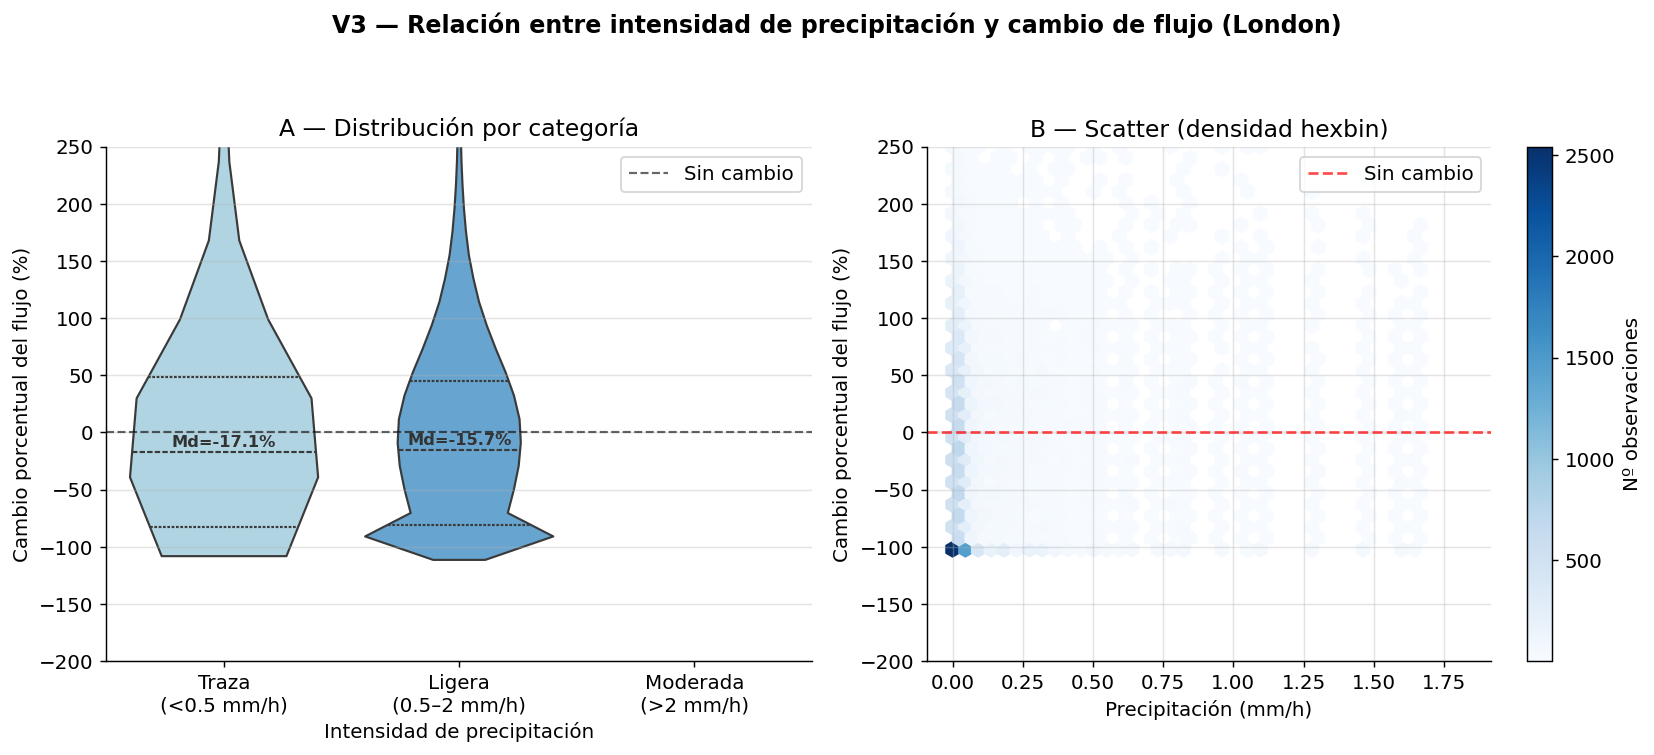

Perfil horario (London): flujo medio con y sin precipitación
has_precip  flow_dry  flow_rain  diff_abs  diff_pct
hour                                               
0              208.6        NaN       NaN       NaN
1              156.5      161.0       4.5       2.9
2              119.8      151.6      31.8      26.5
3              105.4      120.2      14.8      14.0
4              110.6      111.2       0.6       0.5
5              147.7      148.1       0.4       0.3
6              236.0      245.3       9.3       3.9
7              279.8      301.0      21.2       7.6
8              300.4      318.3      17.9       6.0
9              313.3      304.3      -9.0      -2.9
10             322.1      308.4     -13.7      -4.2
11             326.8      316.4     -10.4      -3.2
12             335.8      325.1     -10.7      -3.2
13             336.5      330.3      -6.1      -1.8
14             342.7      332.7     -10.0      -2.9
15             347.6      340.0      -7.6      -2.2
16 

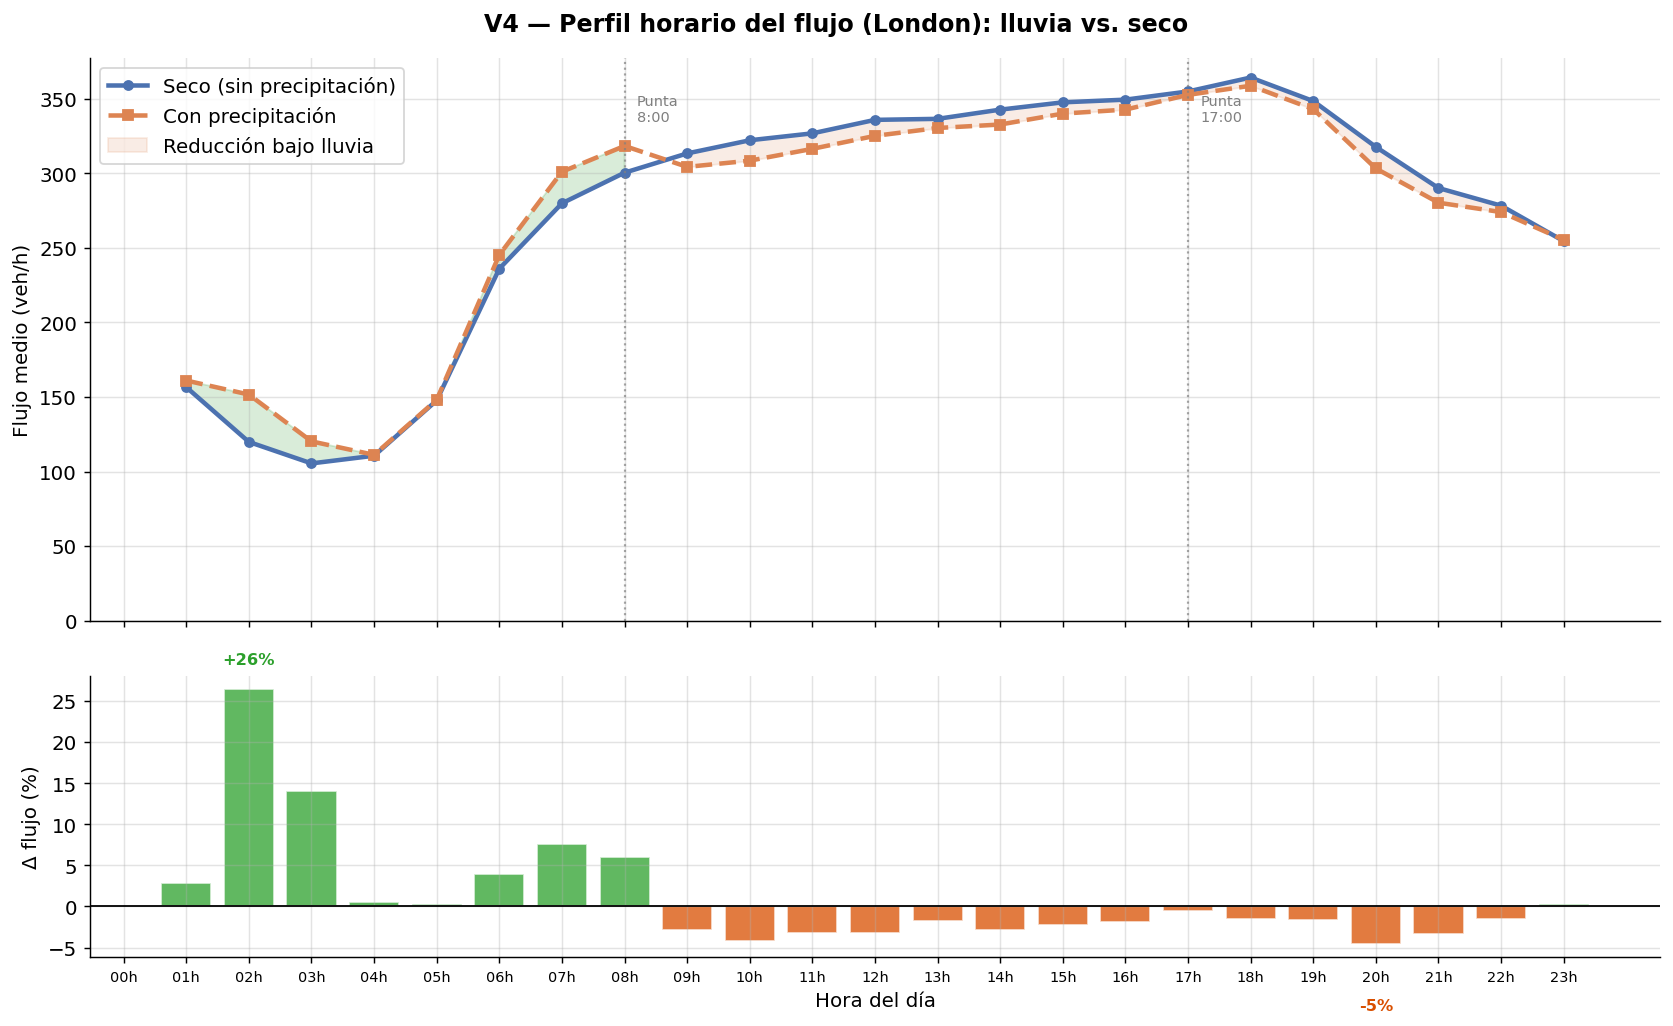

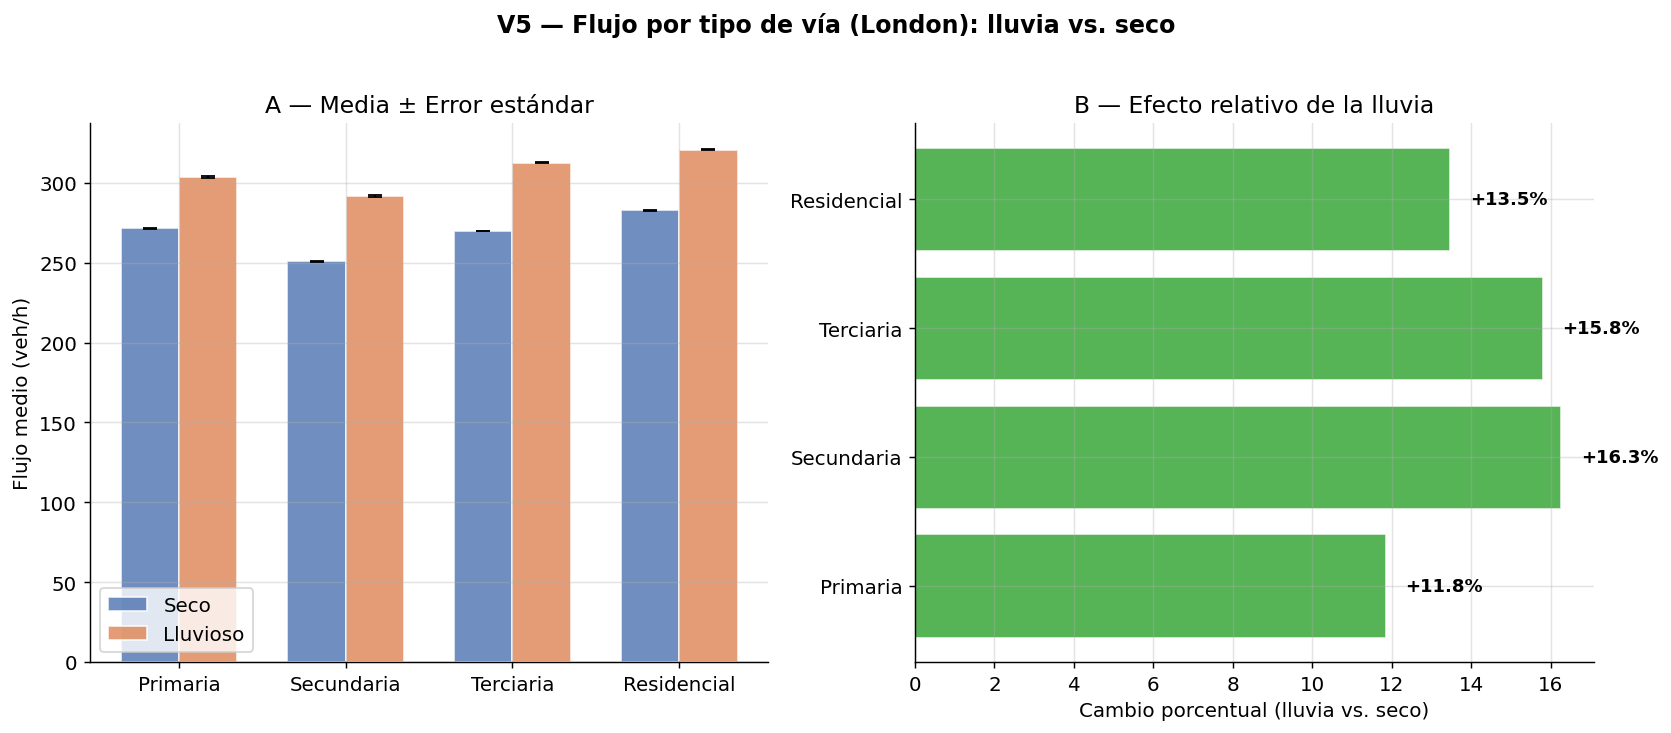

═════════════════════════════════════════════════════════════════
RESUMEN EJECUTIVO DEL EDA — LONDON
═════════════════════════════════════════════════════════════════

▸ V1 — Flujo lluvia vs. seco
   Días secos    : 13  │  μ = 277.9 veh/h
   Días lluviosos: 10  │  μ = 266.4 veh/h
   Efecto global : -4.1%

▸ V3 — Intensidad vs. cambio de flujo
   trace     : mediana=-17.1%  (n=10,844,732, IQR=[-82%, +49%])
   light     : mediana=-15.7%  (n=961,944, IQR=[-81%, +45%])

▸ Implicaciones para el modelado (Fase 4)
   · La lluvia tiene un efecto real pero moderado y heterogéneo
   · El efecto varía fuertemente por hora del día
   · Se justifica incluir: is_rainy, precip_mm_h, interacciones lluvia×hora
   · Variables temporales (hour, dow) dominarán en importancia de features
═════════════════════════════════════════════════════════════════

INICIANDO EDA PARA: MADRID
[MADRID] Filas analizadas: 5,065,890
[MADRID] Evento principal detectado: 2016-12-16
── Validación 1: Flujo medio lluvia vs. sec

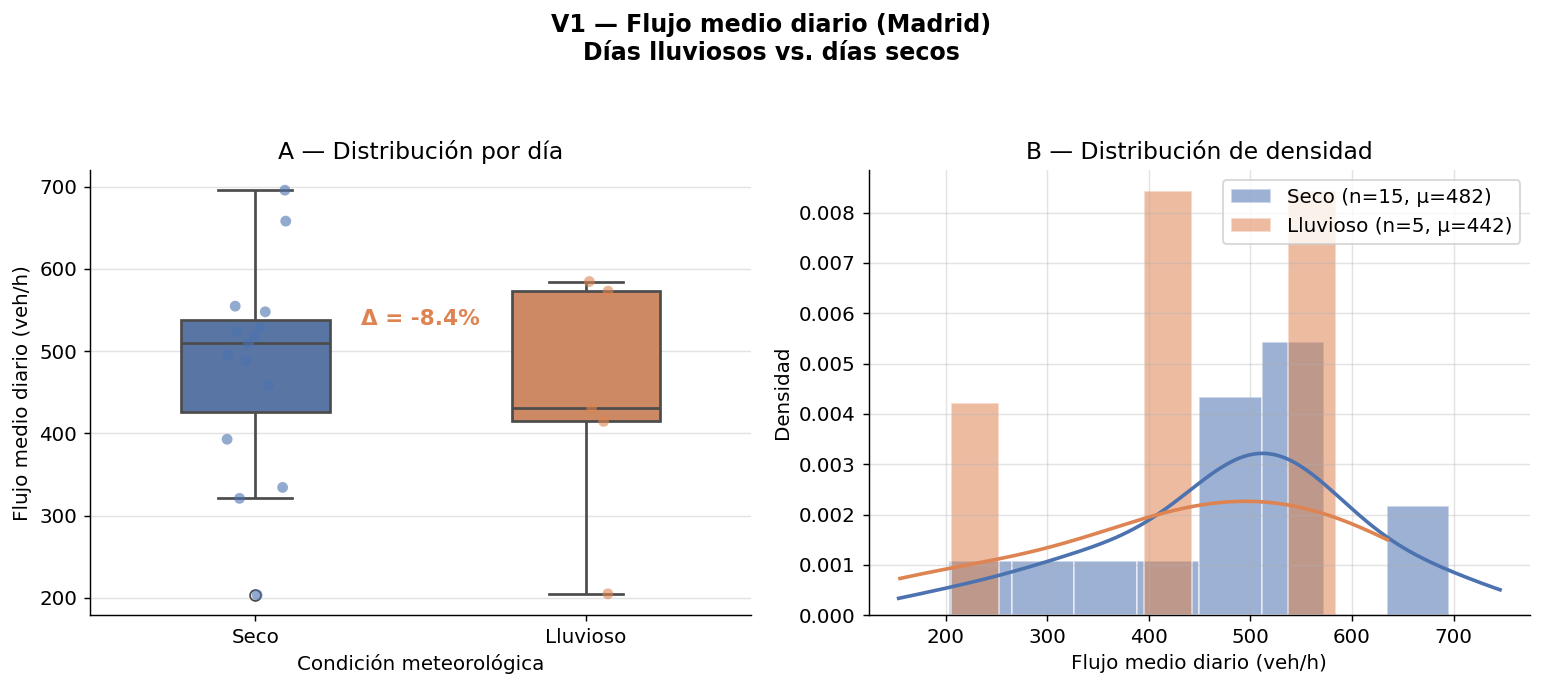

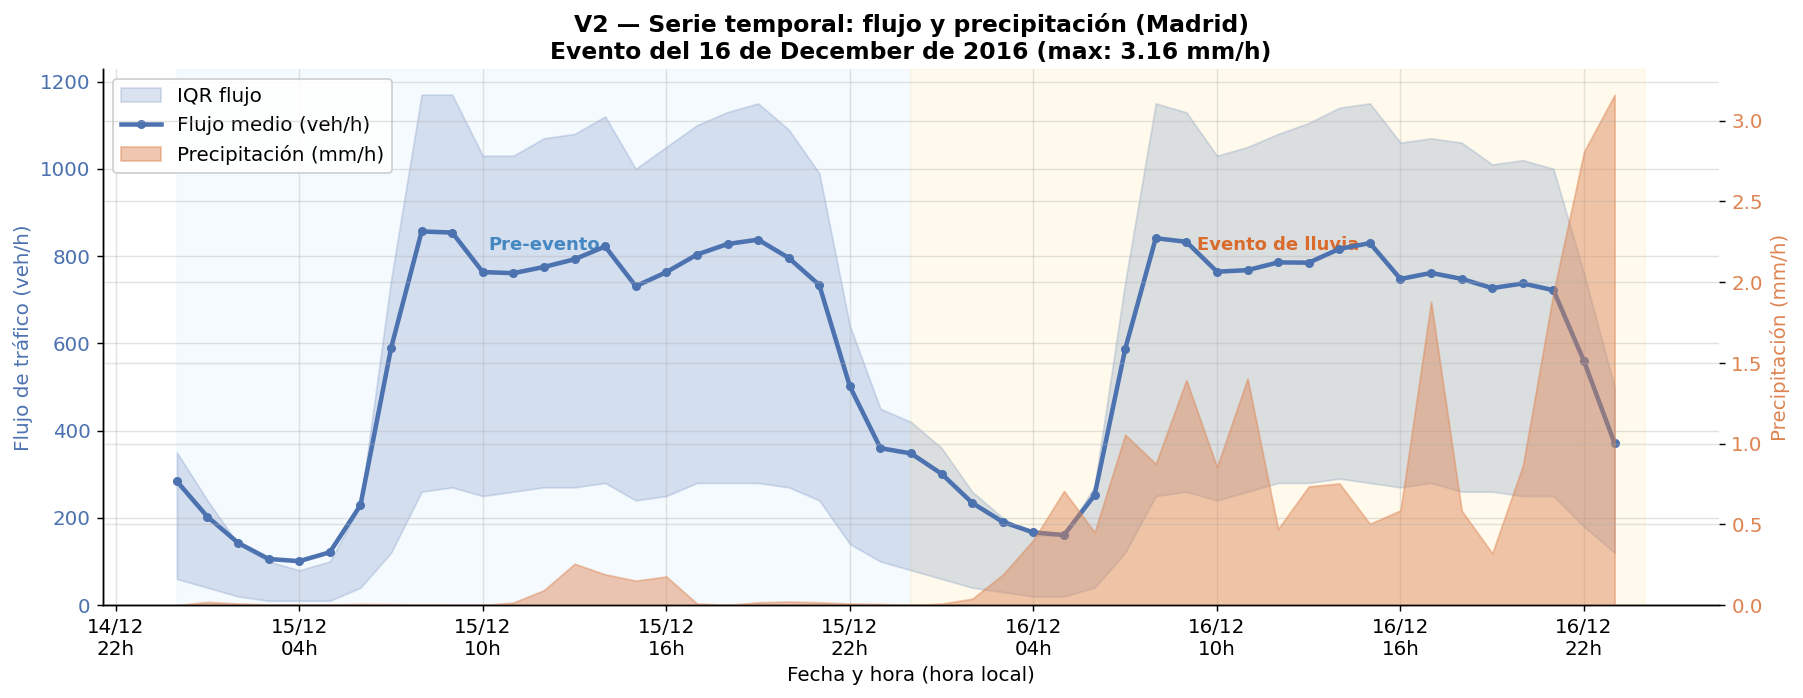

Cambio porcentual del flujo respecto al baseline por intensidad de lluvia (Madrid):
                      n   mean  median    q25    q75
rain_intensity                                      
trace           1070357  11.57  -30.47 -71.46  42.41
light            347798  -1.16  -31.99 -70.12  33.18
moderate          26759  19.25  -13.64 -60.94  62.23

Correlación de Spearman (precip_mm_h vs flow_pct_change):
  ρ = 0.0254,  p = 1.2968e-08


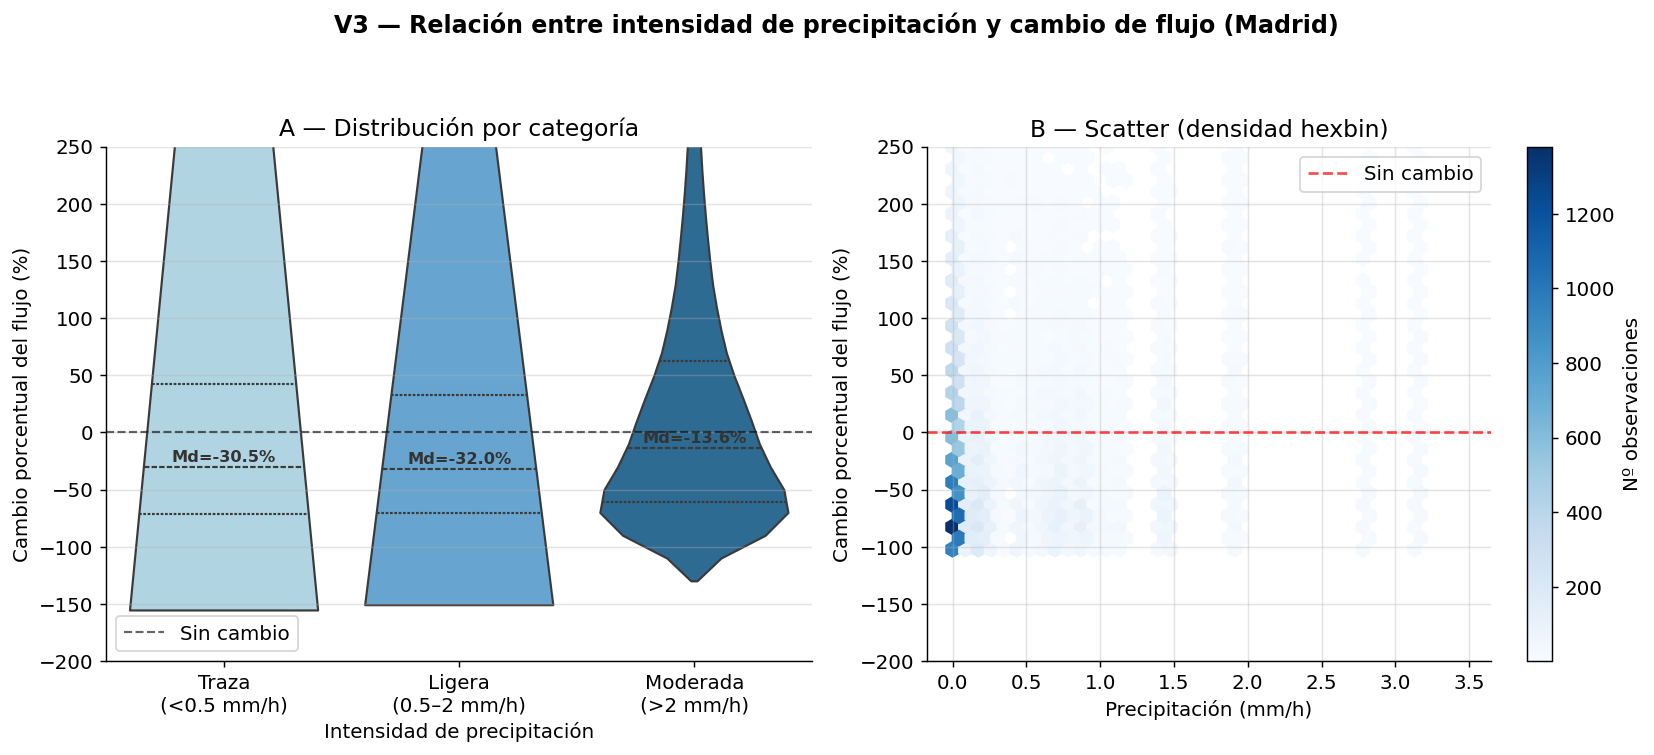

Perfil horario (Madrid): flujo medio con y sin precipitación
has_precip  flow_dry  flow_rain  diff_abs  diff_pct
hour                                               
0              229.2      189.2     -40.0     -17.5
1              132.0      264.8     132.8     100.6
2               94.2      203.2     109.0     115.7
3               76.6      133.6      57.0      74.5
4               66.6      140.1      73.5     110.4
5               83.7      139.3      55.5      66.3
6              180.7      211.9      31.2      17.3
7              484.6      468.7     -15.9      -3.3
8              729.7      719.3     -10.4      -1.4
9              738.6      729.5      -9.0      -1.2
10             683.0      627.4     -55.6      -8.1
11             685.2      675.1     -10.1      -1.5
12             699.5      692.0      -7.5      -1.1
13             694.6      707.6      12.9       1.9
14             724.6      754.5      29.9       4.1
15             645.5      721.6      76.2      11.8
16 

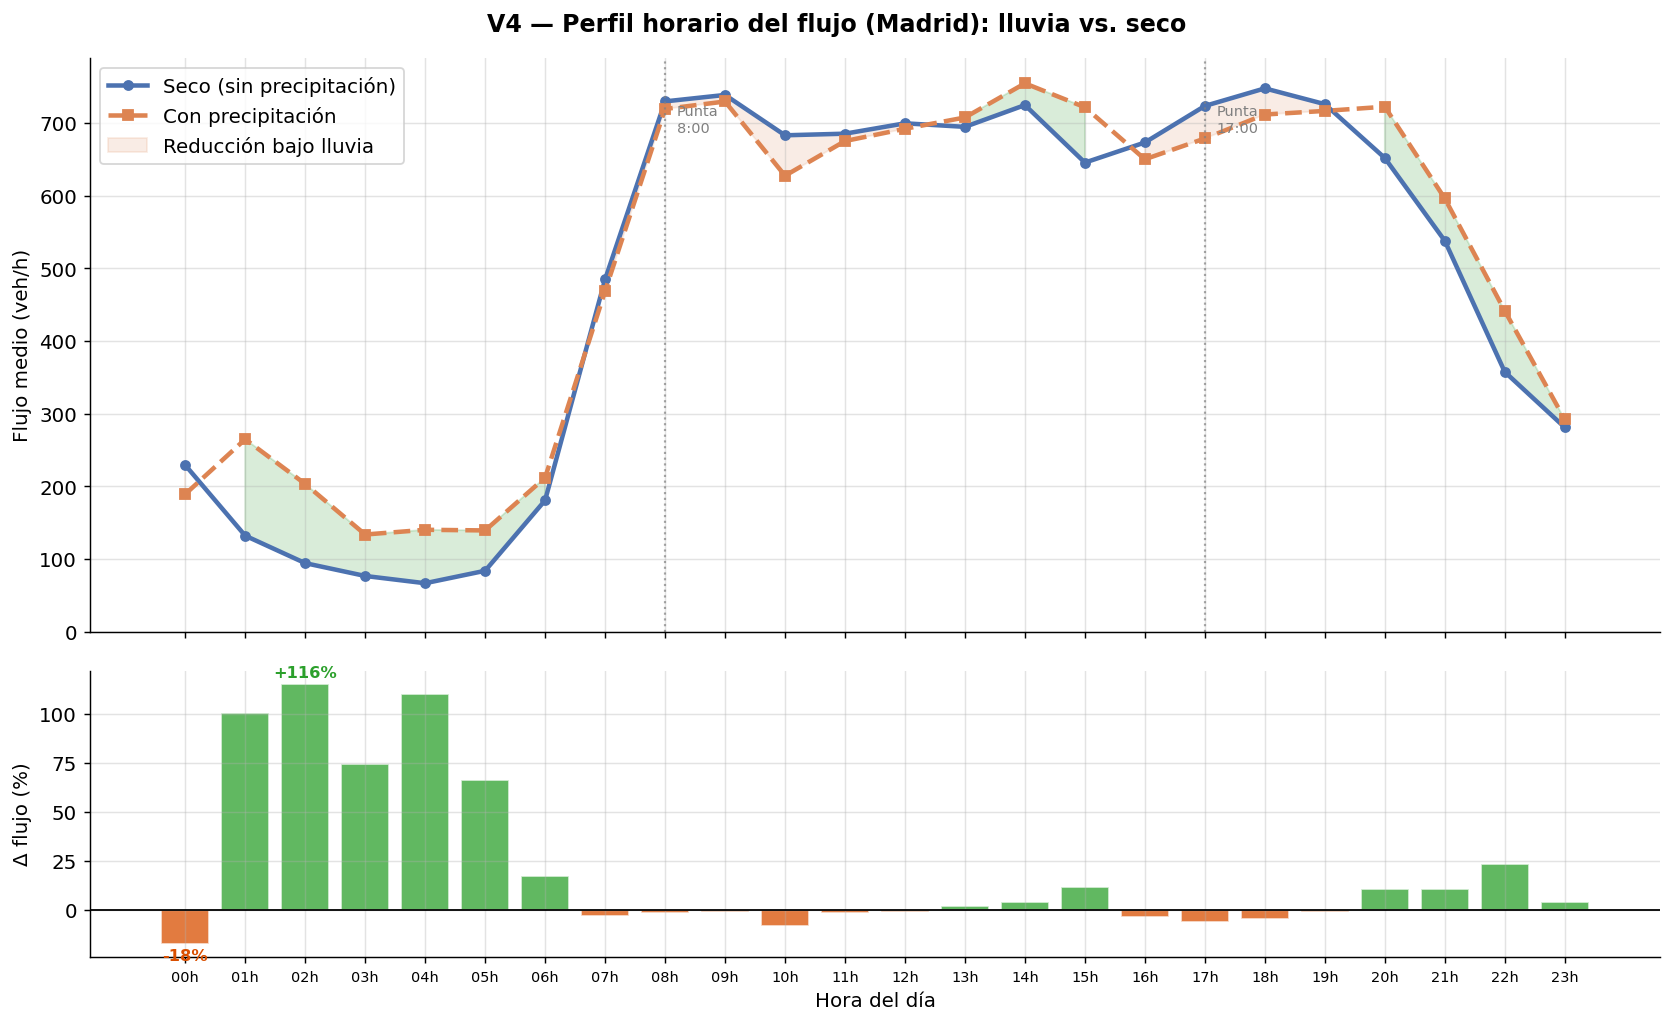

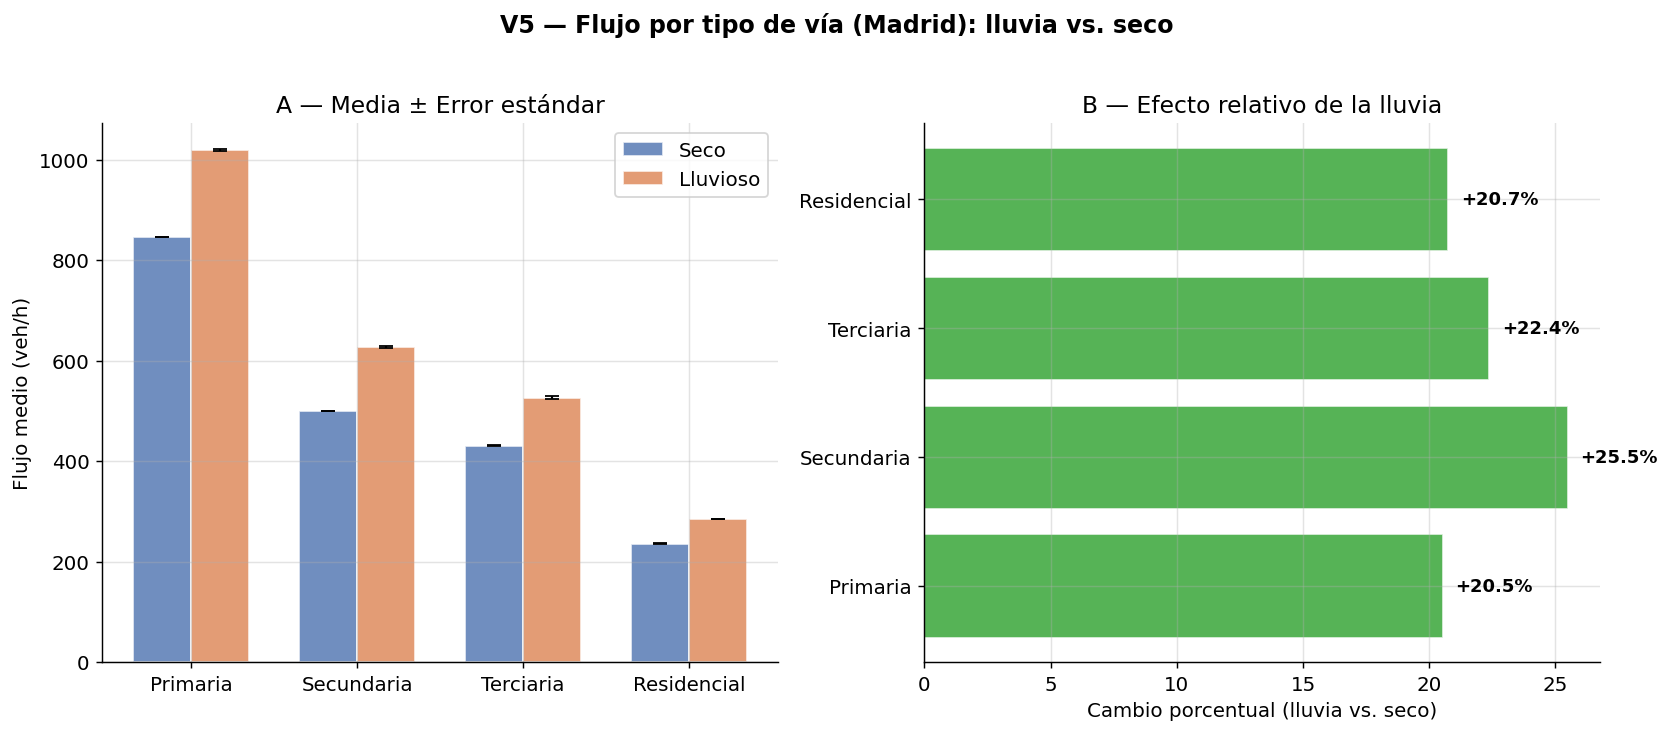

═════════════════════════════════════════════════════════════════
RESUMEN EJECUTIVO DEL EDA — MADRID
═════════════════════════════════════════════════════════════════

▸ V1 — Flujo lluvia vs. seco
   Días secos    : 15  │  μ = 482.0 veh/h
   Días lluviosos:  5  │  μ = 441.7 veh/h
   Efecto global : -8.4%

▸ V3 — Intensidad vs. cambio de flujo
   trace     : mediana=-30.5%  (n=1,070,357, IQR=[-71%, +42%])
   light     : mediana=-32.0%  (n=347,798, IQR=[-70%, +33%])
   moderate  : mediana=-13.6%  (n=26,759, IQR=[-61%, +62%])

▸ Implicaciones para el modelado (Fase 4)
   · La lluvia tiene un efecto real pero moderado y heterogéneo
   · El efecto varía fuertemente por hora del día
   · Se justifica incluir: is_rainy, precip_mm_h, interacciones lluvia×hora
   · Variables temporales (hour, dow) dominarán en importancia de features
═════════════════════════════════════════════════════════════════

INICIANDO EDA PARA: SANTANDER
[SANTANDER] Filas analizadas: 490,136
[SANTANDER] Evento principal

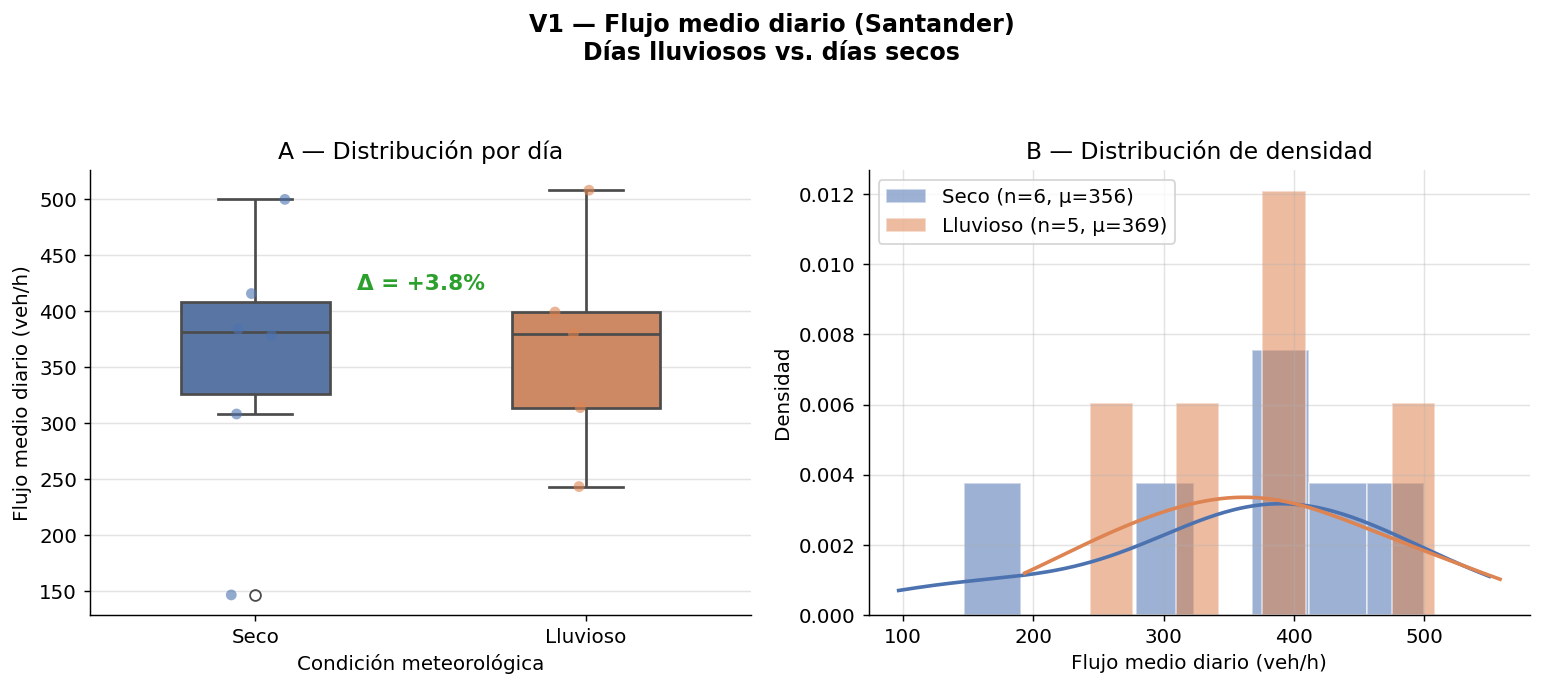

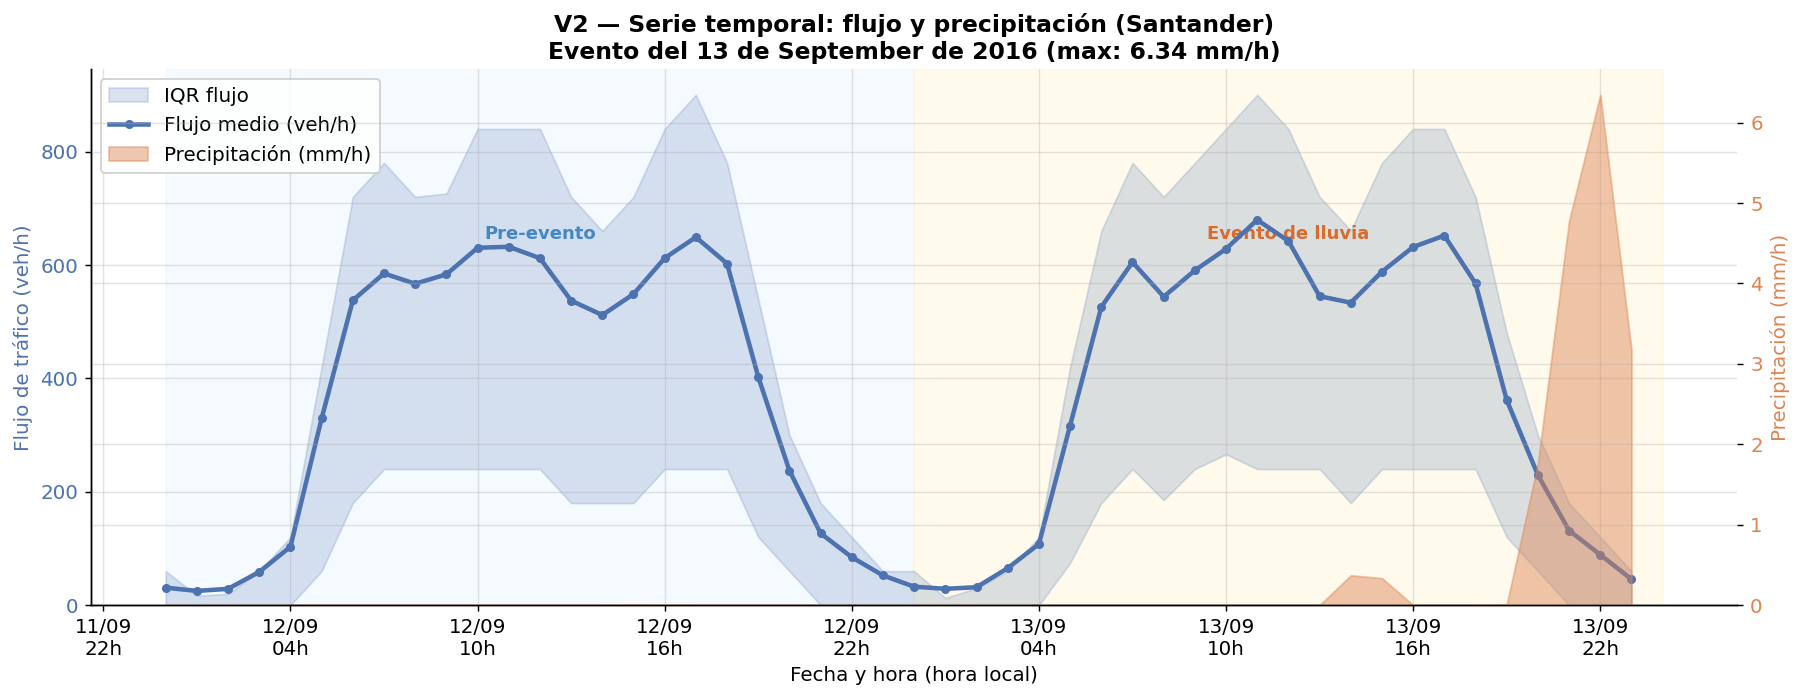

Cambio porcentual del flujo respecto al baseline por intensidad de lluvia (Santander):
                     n  mean  median   q25    q75
rain_intensity                                   
trace           114756  0.88  -29.81 -64.5  26.65

Correlación de Spearman (precip_mm_h vs flow_pct_change):
  ρ = 0.0124,  p = 5.6857e-03


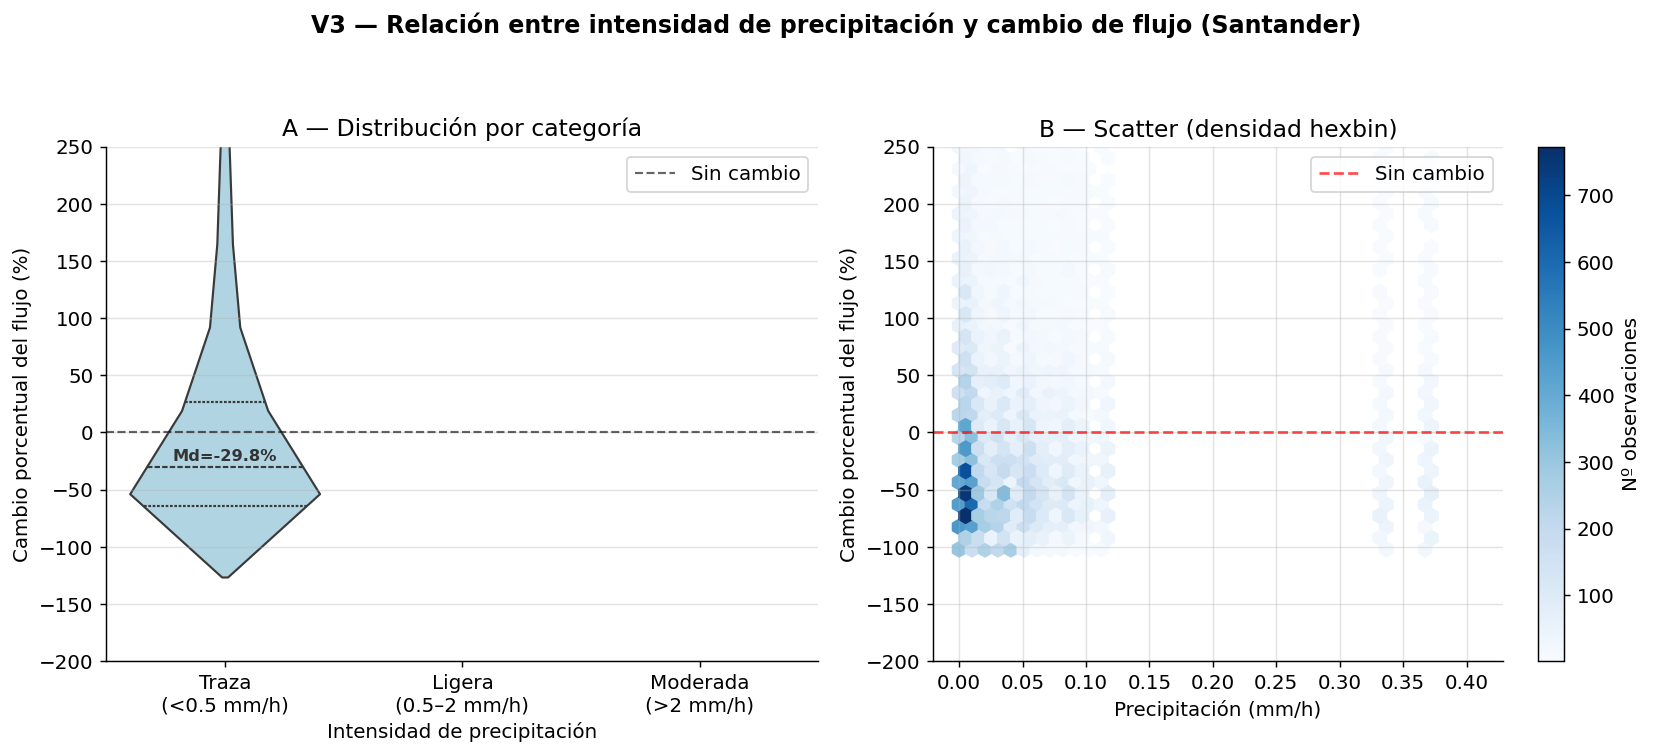

Perfil horario (Santander): flujo medio con y sin precipitación
has_precip  flow_dry  flow_rain  diff_abs  diff_pct
hour                                               
0               46.2      164.7     118.5     256.4
1               66.1        NaN       NaN       NaN
2               36.3       89.5      53.2     146.3
3               50.2       78.7      28.5      56.9
4               79.7       87.8       8.1      10.2
5              202.6       88.0    -114.7     -56.6
6              322.5      270.6     -51.8     -16.1
7              562.1      256.8    -305.3     -54.3
8              582.5      179.6    -402.9     -69.2
9              580.1      229.1    -351.0     -60.5
10             614.8      315.9    -298.8     -48.6
11             642.5      403.4    -239.1     -37.2
12             650.9      461.3    -189.6     -29.1
13             622.4      516.8    -105.7     -17.0
14             569.5      516.9     -52.6      -9.2
15             595.4      479.7    -115.8     -19.4


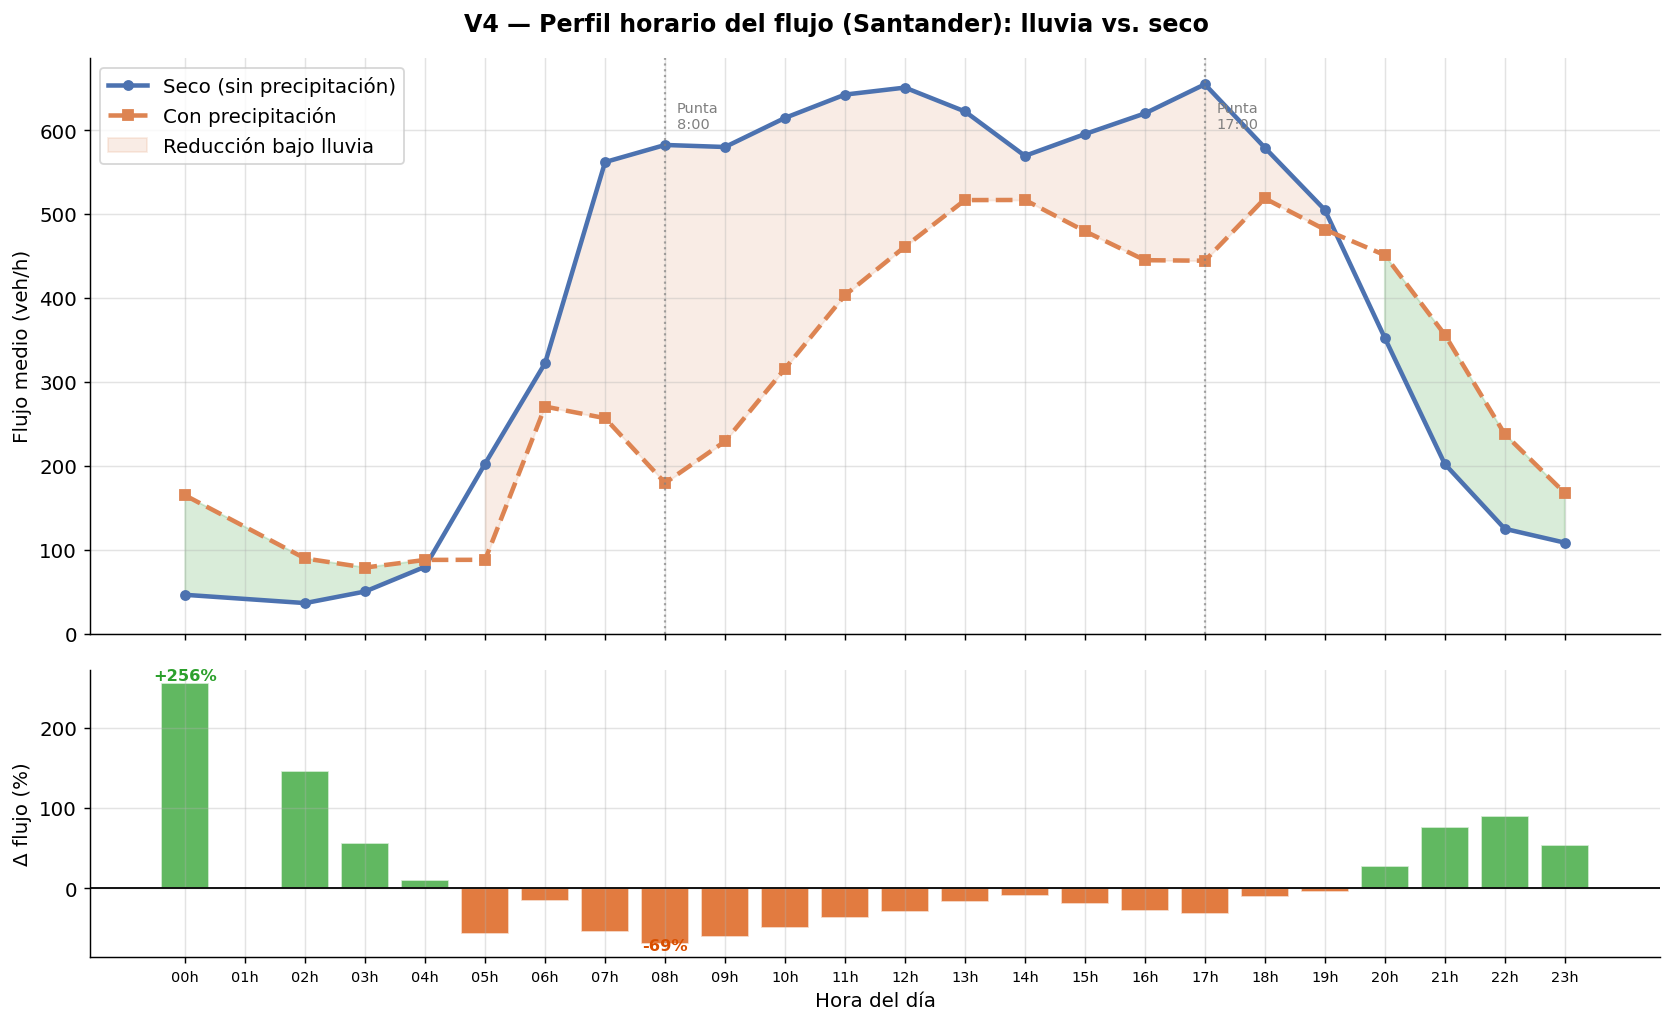

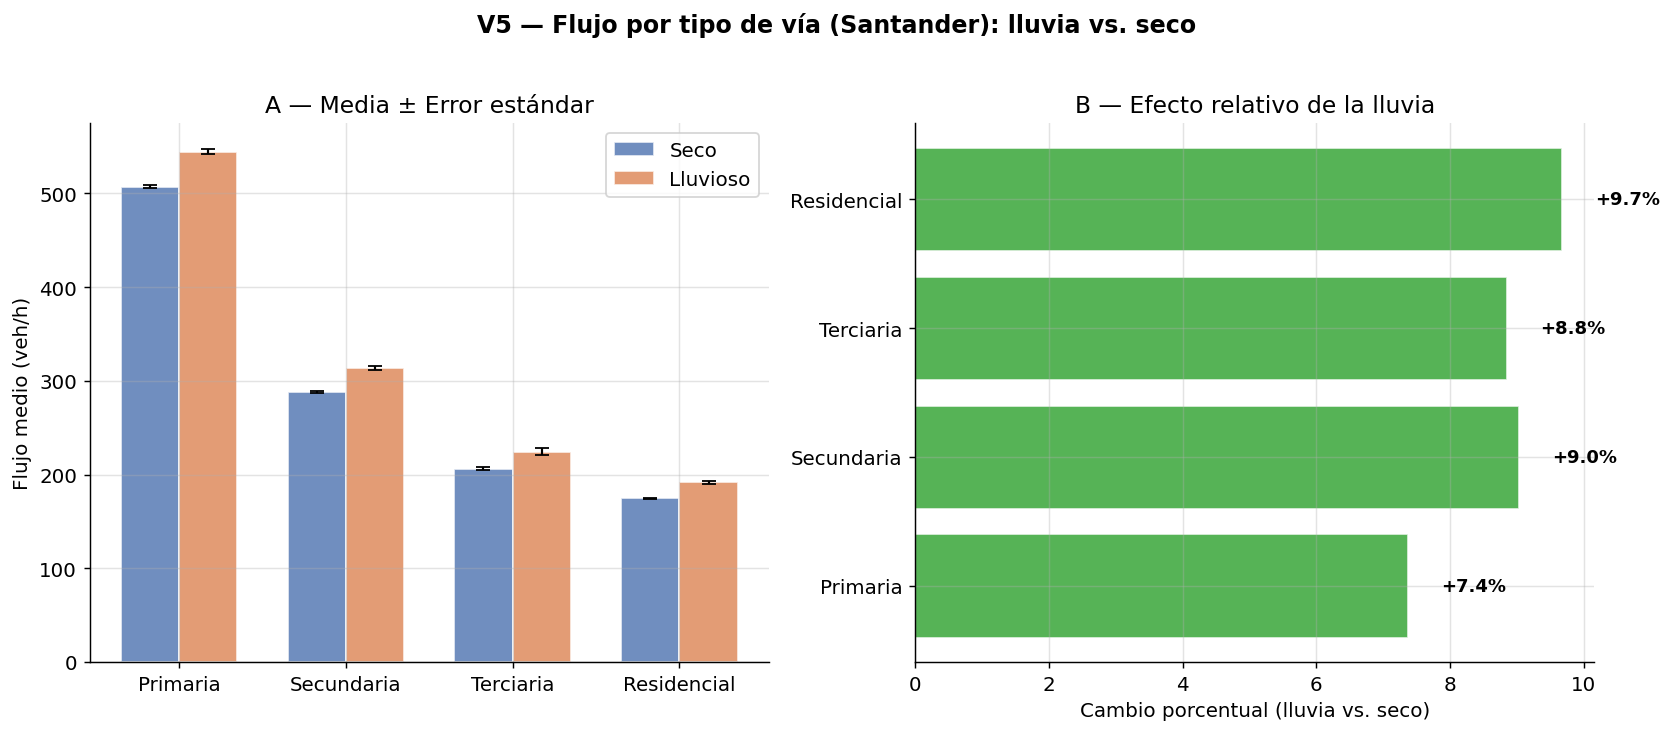

═════════════════════════════════════════════════════════════════
RESUMEN EJECUTIVO DEL EDA — SANTANDER
═════════════════════════════════════════════════════════════════

▸ V1 — Flujo lluvia vs. seco
   Días secos    :  6  │  μ = 355.6 veh/h
   Días lluviosos:  5  │  μ = 369.1 veh/h
   Efecto global : +3.8%

▸ V3 — Intensidad vs. cambio de flujo
   trace     : mediana=-29.8%  (n=114,756, IQR=[-64%, +27%])

▸ Implicaciones para el modelado (Fase 4)
   · La lluvia tiene un efecto real pero moderado y heterogéneo
   · El efecto varía fuertemente por hora del día
   · Se justifica incluir: is_rainy, precip_mm_h, interacciones lluvia×hora
   · Variables temporales (hour, dow) dominarán en importancia de features
═════════════════════════════════════════════════════════════════


In [76]:
# ── Bucle Principal de Ejecución de EDA por Ciudad ──────────────────────────

for city_dir in city_dirs:
    city_name = city_dir.name
    print(f"\n{'='*70}")
    print(f"INICIANDO EDA PARA: {city_name.upper()}")
    print(f"{'='*70}")
    
    # Rutas dinámicas
    dataset_path = city_dir / f"{city_name}_analytical_dataset.parquet"
    figures_dir = Path(f"../data/debug/output/figures/{city_name}")
    figures_dir.mkdir(parents=True, exist_ok=True)
    
    if not dataset_path.exists():
        print(f"[{city_name.upper()}] No se encontró dataset analítico en {dataset_path}. Se omite.")
        continue
        
    try:
        # 1. Cargar datos
        df = load_analytical_dataset(dataset_path)
        print(f"[{city_name.upper()}] Filas analizadas: {len(df):,}")
        
        # Encontrar el evento de lluvia más intenso
        event_date = get_top_event_date(df)
        print(f"[{city_name.upper()}] Evento principal detectado: {event_date.strftime('%Y-%m-%d')}")
        
        # 2. Precalcular transformaciones
        daily = compute_daily_summary(df)
        baseline = compute_flow_baseline(df)
        rainy_vs_baseline = compute_pct_change_vs_baseline(df, baseline)
        
        # 3. Validación 1
        compute_and_print_v1_stats(daily, city_name)
        plot_v1_rain_vs_dry(daily, city_name, figures_dir)
        
        # 4. Validación 2
        event_window = get_event_window(df, event_date)
        plot_v2_event_window(event_window, city_name, event_date, figures_dir)
        
        # 5. Validación 3
        intensity_stats = compute_intensity_stats(rainy_vs_baseline)
        print_v3_stats(rainy_vs_baseline, intensity_stats, city_name)
        plot_v3_intensity_effect(rainy_vs_baseline, intensity_stats, city_name, figures_dir)
        
        # 6. Validación 4
        hourly_profile = compute_hourly_profile(df)
        print_v4_stats(hourly_profile, city_name)
        plot_v4_hourly_profile(hourly_profile, city_name, figures_dir)
        
        # 7. Validación 5
        plot_v5_fclass_effect(df, city_name, figures_dir)
        
        # 8. Resumen Global
        print_eda_summary(df, daily, intensity_stats, city_name)
        
    except Exception as e:
        print(f"[{city_name.upper()}] Error durante el EDA: {e}")

In [77]:
# ── Diagnóstico Rápido: Lluvia máxima por ciudad en el dataset 'debug' ─────
import pandas as pd
from pathlib import Path

# Buscamos directamente en los archivos originales 'input'
input_base_path = Path(r"../data/debug/input")
cities = sorted([p for p in input_base_path.iterdir() if p.is_dir()])

print("DIAGNÓSTICO DE PRECIPITACIÓN ORIGINAL (ERA5)")
print(f"{'Ciudad':<15} | {'Prec. Máx (mm/h)':<18} | {'Categoría'}")
print("-" * 50)

for city in cities:
    weather_dir = city / "weather" / "datetime"
    
    if not weather_dir.exists():
         print(f"{city.name:<15} | {'Sin carpeta':<18} | N/A")
         continue
         
    files = list(weather_dir.glob("*.parquet"))
    if not files:
         print(f"{city.name:<15} | {'Sin archivos':<18} | N/A")
         continue
         
    max_rain = 0
    for f in files:
        df_weather = pd.read_parquet(f)
        if "total_precipitation" in df_weather.columns:
             # Convertir de metros/hora a mm/hora
             m = df_weather["total_precipitation"].max() * 1000.0
             if m > max_rain:
                 max_rain = m
                 
    if max_rain > 2.0:
         cat = "Moderada (>2)"
    elif max_rain > 0.5:
         cat = "Ligera (0.5-2)"
    elif max_rain > 0.0001:
         cat = "Traza (<0.5)"
    else:
         cat = "Seco (0)"
         
    print(f"{city.name:<15} | {max_rain:<18.4f} | {cat}")

DIAGNÓSTICO DE PRECIPITACIÓN ORIGINAL (ERA5)
Ciudad          | Prec. Máx (mm/h)   | Categoría
--------------------------------------------------
london          | 3.1328             | Moderada (>2)
madrid          | 3.4509             | Moderada (>2)
santander       | 6.3438             | Moderada (>2)
